# Projet ML : Prédiction du Montant FDE et Comportement des Abonnés

---

##  **Objectifs du Projet**

1. **Régression** : Prédire `MONT-FDE` (montant du Fonds de Développement de l'Eau)
2. **Classification** : Prédire `RETARD` (retard de paiement)
3. **Classification** : Prédire `RESILIE` (résiliation de l'abonné)
4. **Sélection de variables** : Identifier les variables les plus importantes

---

##  **Structure du Notebook**

###  **PARTIE 1 : EXPLORATION DES DONNÉES (EDA)**
- Chargement des données
- Analyse de la structure
- Création du dictionnaire de données
- Analyse des valeurs manquantes
- Visualisations

###  **PARTIE 2 : PREPROCESSING**
- Split train/test (80/20)
- Traitement des dates
- Création des variables dérivées
- Traitement des valeurs manquantes
- Encodage des variables catégorielles
- Normalisation

###  **PARTIE 3 : MODÉLISATION** (à compléter)
- Régression
- Classification
- Sélection de variables

###  **GROUPE:
1. **MOUHI CHRIST-EMMANUEL** 
2. **FOFANA ADELPHE VIANNEY** 
3. **MEITE YOUSSOUF** 
4. **COULIBALY SEGNINDENIN OUMAR** 


---

#  PARTIE 1 : EXPLORATION DES DONNÉES (EDA)

---

##  1.1 - Installation et Import des Bibliothèques

In [1]:
# Import des bibliothèques
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
import warnings
import os
from datetime import datetime

# Configuration
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)

print(" Bibliothèques importées avec succès !")
print(f"   - pandas version : {pd.__version__}")
print(f"   - numpy version : {np.__version__}")

 Bibliothèques importées avec succès !
   - pandas version : 2.2.3
   - numpy version : 2.0.2


##  1.2 - Configuration des Chemins

In [2]:
CHEMIN_DOSSIER = "Data"

# Liste des fichiers à charger
FICHIERS = ["DR2.txt", "DR6.txt", "DR7.txt", "DR9.txt", "DR16.txt", "DR21.txt"]

# Vérifier que le dossier existe
if os.path.exists(CHEMIN_DOSSIER):
    print(f" Dossier trouvé : {CHEMIN_DOSSIER}")
    print(f"\n Fichiers à charger :")
    for fichier in FICHIERS:
        filepath = os.path.join(CHEMIN_DOSSIER, fichier)
        if os.path.exists(filepath):
            taille = os.path.getsize(filepath) / (1024**2)  # En MB
            print(f"   ✓ {fichier} ({taille:.2f} MB)")
        else:
            print(f"   ✗ {fichier} - NON TROUVÉ")
else:
    print(f" Dossier introuvable !")
    print(f"   Veuillez mettre à jour CHEMIN_DOSSIER")

 Dossier trouvé : Data

 Fichiers à charger :
   ✓ DR2.txt (275.48 MB)
   ✓ DR6.txt (227.41 MB)
   ✓ DR7.txt (253.69 MB)
   ✓ DR9.txt (114.06 MB)
   ✓ DR16.txt (239.65 MB)
   ✓ DR21.txt (430.40 MB)


##  1.3 - Chargement des Données


In [3]:
def charger_fichier(filepath):
    """Charge un fichier avec gestion d'erreurs"""
    nom_fichier = os.path.basename(filepath)
    print(f" Chargement de {nom_fichier}...", end=" ")
    
    try:
        df = pd.read_csv(filepath, sep=',', encoding='utf-8', low_memory=False)
        df['SOURCE_FICHIER'] = nom_fichier.replace('.txt', '')
        print(f" {len(df):,} lignes")
        return df
    except Exception as e:
        print(f"❌ Erreur : {e}")
        return None

# Charger tous les fichiers
print(" Chargement des 6 fichiers...\n")
dataframes = []

for fichier in FICHIERS:
    filepath = os.path.join(CHEMIN_DOSSIER, fichier)
    if os.path.exists(filepath):
        df = charger_fichier(filepath)
        if df is not None:
            dataframes.append(df)

print(f"\n {len(dataframes)} fichiers chargés avec succès !")

 Chargement des 6 fichiers...

 Chargement de DR2.txt...  1,526,258 lignes
 Chargement de DR6.txt...  1,265,439 lignes
 Chargement de DR7.txt...  1,407,444 lignes
 Chargement de DR9.txt...  634,767 lignes
 Chargement de DR16.txt...  1,323,943 lignes
 Chargement de DR21.txt...  2,346,796 lignes

 6 fichiers chargés avec succès !


In [4]:
# Fusion des DataFrames
print(" Fusion des données...")
df_brut = pd.concat(dataframes, ignore_index=True)

print(f"\n Fusion terminée !")
print(f"   - Total lignes : {len(df_brut):,}")
print(f"   - Total colonnes : {len(df_brut.columns)}")
print(f"   - Mémoire : {df_brut.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

 Fusion des données...

 Fusion terminée !
   - Total lignes : 8,504,647
   - Total colonnes : 36
   - Mémoire : 8142.93 MB


##  1.4 - Aperçu Rapide des Données

In [5]:
# Afficher les premières lignes
print(" Aperçu des 5 premières lignes :\n")
df_brut.head()

 Aperçu des 5 premières lignes :



,DR,CEN,POLICE,O,P,ENR,MM,AAAA,DATE-FACT,DIAM,CUBCONS,CUBFAC,FORFAIT,SOCIAL,DOMEST,NORMAL,INDUST,ADMINI,MONT-SOD,MONT-TVA,MONT-FDE,MONT-FNE,MONT-ASS-TTC,MONT-FRAIS-CPT,MONT-TTC,DATE-ABON,DATE-RESIL,TOURNEE,DATE-REGLT,AAENC,MMENC,RESILIE,CATEGORIE,NOUVEAU,DATE-REGLT-ENC,SOURCE_FICHIER
0,2,7,16948,2,1,EN,12,2016,2016-12-24 00:00:00.000,1,51.0,51,3,3,24,21,0,0,11628,1845,7595,1481,0,0.0,2016-11-24 00:00:00.000,NaN,2015-11-18 00:00:00.000,44.0,2017-01-20 00:00:00.000,2017.0,janv.,1.0,PRIVE,0.0,36,DR2
1,2,7,16949,1,3,EN,3,2016,2016-04-07 00:00:00.000,1,55.0,55,9,9,37,0,0,0,12540,1517,2986,777,0,0.0,2015-11-18 00:00:00.000,NaN,2015-11-18 00:00:00.000,76.0,2016-05-04 00:00:00.000,2016.0,mai,1.0,PRIVE,0.0,27,DR2
2,2,7,16949,1,3,EN,6,2016,2016-07-07 00:00:00.000,1,59.0,59,9,9,41,0,0,0,13452,1681,3295,861,0,0.0,2015-11-18 00:00:00.000,NaN,2015-11-18 00:00:00.000,76.0,2016-08-03 00:00:00.000,2016.0,août,1.0,PRIVE,0.0,30,DR2
3,2,7,16949,1,3,EN,9,2016,2016-10-07 00:00:00.000,1,32.0,32,9,9,14,0,0,0,7296,574,1208,294,0,0.0,2015-11-18 00:00:00.000,NaN,2015-11-18 00:00:00.000,76.0,2016-11-30 00:00:00.000,2016.0,nov.,1.0,PRIVE,0.0,33,DR2
4,2,7,16949,1,3,EN,12,2016,2017-01-07 00:00:00.000,1,37.0,37,9,9,19,0,0,0,8436,779,1595,399,0,0.0,2015-11-18 00:00:00.000,NaN,2015-11-18 00:00:00.000,76.0,2017-03-03 00:00:00.000,2017.0,mars,1.0,PRIVE,0.0,36,DR2


In [6]:
# Structure du DataFrame
print(" Structure du DataFrame :\n")
df_brut.info()

 Structure du DataFrame :

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8504647 entries, 0 to 8504646
Data columns (total 36 columns):
 #   Column          Dtype  
---  ------          -----  
 0   DR              int64  
 1   CEN             int64  
 2   POLICE          int64  
 3   O               int64  
 4   P               int64  
 5   ENR             object 
 6   MM              int64  
 7   AAAA            int64  
 8   DATE-FACT       object 
 9   DIAM            int64  
 10  CUBCONS         float64
 11  CUBFAC          int64  
 12  FORFAIT         int64  
 13  SOCIAL          int64  
 14  DOMEST          int64  
 15  NORMAL          int64  
 16  INDUST          int64  
 17  ADMINI          int64  
 18  MONT-SOD        object 
 19  MONT-TVA        object 
 20  MONT-FDE        object 
 21  MONT-FNE        object 
 22  MONT-ASS-TTC    object 
 23  MONT-FRAIS-CPT  float64
 24  MONT-TTC        object 
 25  DATE-ABON       object 
 26  DATE-RESIL      object 
 27  TOURNEE       

In [7]:
# Liste des colonnes
print(f" Liste des {len(df_brut.columns)} colonnes :\n")
for i, col in enumerate(df_brut.columns, 1):
    print(f"   {i:2d}. {col}")

 Liste des 36 colonnes :

    1. DR
    2. CEN
    3. POLICE
    4. O
    5. P
    6. ENR
    7. MM
    8. AAAA
    9. DATE-FACT
   10. DIAM
   11. CUBCONS
   12. CUBFAC
   13. FORFAIT
   14. SOCIAL
   15. DOMEST
   16. NORMAL
   17. INDUST
   18. ADMINI
   19. MONT-SOD
   20. MONT-TVA
   21. MONT-FDE
   22. MONT-FNE
   23. MONT-ASS-TTC
   24. MONT-FRAIS-CPT
   25. MONT-TTC
   26. DATE-ABON
   27. DATE-RESIL
   28. TOURNEE
   29. DATE-REGLT
   30. AAENC
   31. MMENC
   32. RESILIE
   33. CATEGORIE
   34. NOUVEAU
   35. DATE-REGLT-ENC
   36. SOURCE_FICHIER


## 1.5 - Création du Dictionnaire de Données

Analyse détaillée de chaque variable basée sur les données.

In [7]:
def creer_dictionnaire_donnees(df):
    """Crée un dictionnaire complet des variables"""
    dictionnaire = []
    
    for col in df.columns:
        if col == 'SOURCE_FICHIER':
            continue
        
        info = {
            'Variable': col,
            'Type': str(df[col].dtype),
            'Non_Nulls': df[col].count(),
            'Pct_Rempli': f"{df[col].count() / len(df) * 100:.2f}%",
            'Valeurs_Uniques': df[col].nunique(),
            'Manquantes': df[col].isnull().sum(),
            'Pct_Manquant': f"{df[col].isnull().sum() / len(df) * 100:.2f}%"
        }
        
        # Nature de la variable
        if 'DATE' in col.upper():
            info['Nature'] = 'DATE'
        elif pd.api.types.is_numeric_dtype(df[col]):
            info['Nature'] = 'QUANTITATIVE'
            info['Min'] = df[col].min()
            info['Max'] = df[col].max()
            info['Moyenne'] = f"{df[col].mean():.2f}"
            info['Mediane'] = df[col].median()
            if df[col].nunique() == 2:
                info['Nature'] = 'BINAIRE'
        else:
            info['Nature'] = 'QUALITATIVE'
        
        dictionnaire.append(info)
    
    return pd.DataFrame(dictionnaire)

# Créer le dictionnaire
print(" Création du dictionnaire de données...\n")
df_dict = creer_dictionnaire_donnees(df_brut)

print(f" Dictionnaire créé : {len(df_dict)} variables documentées\n")
df_dict

 Création du dictionnaire de données...

 Dictionnaire créé : 35 variables documentées



,Variable,Type,Non_Nulls,Pct_Rempli,Valeurs_Uniques,Manquantes,Pct_Manquant,Nature,Min,Max,Moyenne,Mediane
0,DR,int64,8504647,100.00%,6,0,0.00%,QUANTITATIVE,2.0,21.0,11.37,9.0
1,CEN,int64,8504647,100.00%,96,0,0.00%,QUANTITATIVE,2.0,199.0,70.30,47.0
2,POLICE,int64,8504647,100.00%,62710,0,0.00%,QUANTITATIVE,1.0,99999.0,14018.75,7921.0
3,O,int64,8504647,100.00%,9,0,0.00%,QUANTITATIVE,1.0,9.0,1.91,1.0
4,P,int64,8504647,100.00%,3,0,0.00%,QUANTITATIVE,0.0,3.0,2.87,3.0
5,ENR,object,8504647,100.00%,4,0,0.00%,QUALITATIVE,NaN,NaN,NaN,NaN
6,MM,int64,8504647,100.00%,12,0,0.00%,QUANTITATIVE,1.0,12.0,6.54,7.0
7,AAAA,int64,8504647,100.00%,6,0,0.00%,QUANTITATIVE,2014.0,2019.0,2016.65,2017.0
8,DATE-FACT,object,8504647,100.00%,2119,0,0.00%,DATE,NaN,NaN,NaN,NaN
9,DIAM,int64,8504647,100.00%,18,0,0.00%,QUANTITATIVE,1.0,200.0,1.99,1.0


##  1.6 - Analyse des Valeurs Manquantes

  11 variables avec valeurs manquantes :



,Variable,Nb_Manquantes,Pct_Manquant
25,DATE-ABON,7747832,91.10
26,DATE-RESIL,1486990,17.48
24,MONT-TTC,586242,6.89
31,RESILIE,572620,6.73
33,NOUVEAU,540679,6.36
23,MONT-FRAIS-CPT,514273,6.05
30,MMENC,388029,4.56
29,AAENC,388029,4.56
28,DATE-REGLT,388029,4.56
27,TOURNEE,46286,0.54


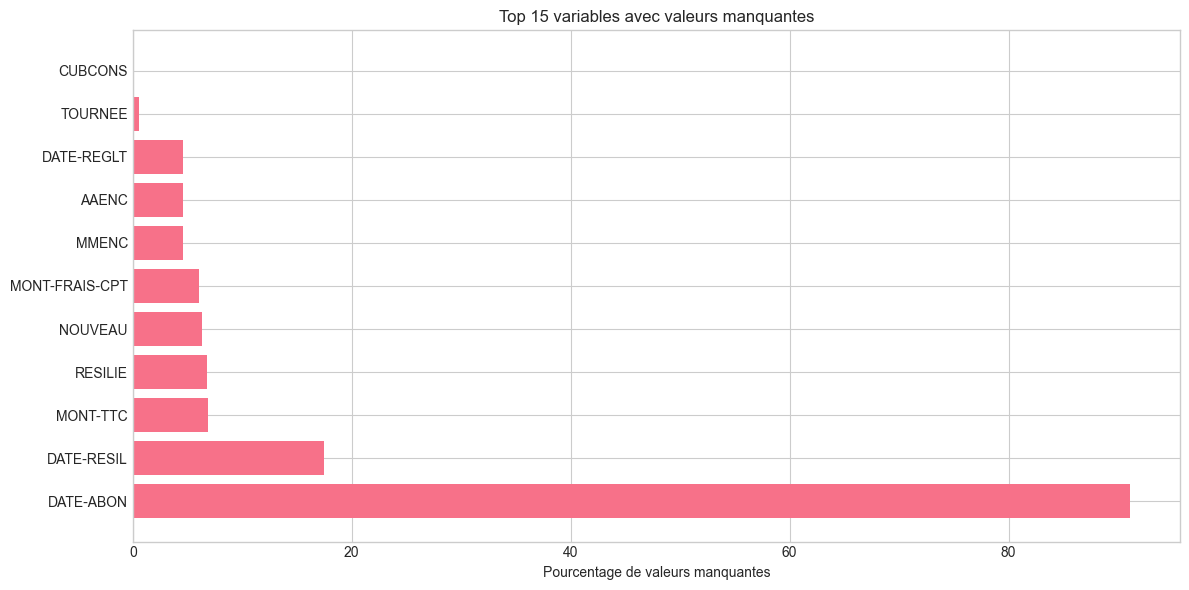

In [9]:
# Calculer les valeurs manquantes
missing = df_brut.isnull().sum()
missing_pct = (missing / len(df_brut) * 100).round(2)

missing_df = pd.DataFrame({
    'Variable': missing.index,
    'Nb_Manquantes': missing.values,
    'Pct_Manquant': missing_pct.values
})

missing_df = missing_df[missing_df['Nb_Manquantes'] > 0].sort_values('Pct_Manquant', ascending=False)

if len(missing_df) > 0:
    print(f"  {len(missing_df)} variables avec valeurs manquantes :\n")
    display(missing_df)
    
    # Visualisation
    plt.figure(figsize=(12, 6))
    plt.barh(missing_df['Variable'].head(15), missing_df['Pct_Manquant'].head(15))
    plt.xlabel('Pourcentage de valeurs manquantes')
    plt.title('Top 15 variables avec valeurs manquantes')
    plt.tight_layout()
    plt.show()
else:
    print(" Aucune valeur manquante détectée !")

In [10]:
# Vérifier si ces colonnes existent et sont remplies
print("TOURNEE :", df_brut['TOURNEE'].nunique(), "tournées uniques")
print("AAENC :", df_brut['AAENC'].value_counts().sort_index())
print("MMENC :", df_brut['MMENC'].value_counts().sort_index())
print("DATE-REGLT-ENC vs DATE-REGLT :")
print("  - DATE-REGLT non null :", df_brut['DATE-REGLT'].notna().sum())
print("  - DATE-REGLT-ENC non null :", df_brut['DATE-REGLT-ENC'].notna().sum())

TOURNEE : 473 tournées uniques
AAENC : AAENC
2011.0          1
2013.0          6
2014.0     871296
2015.0    1221018
2016.0    1285390
2017.0    1421747
2018.0    1582270
2019.0    1427436
2020.0     307454
Name: count, dtype: int64
MMENC : MMENC
1        123586
10       121321
11       104962
12       111398
2        106329
3        111116
4        108494
5        102465
6        102341
7        123700
8        104431
9        108634
aoÃ»t     76882
août     459534
avr       84241
avr.     475147
dÃ©c      89626
déc.     520166
fÃ©vr     80163
févr.    456651
janv      93848
janv.    494441
juil      92101
juil.    482840
juin     545446
mai      581175
mars     611156
nov       77862
nov.     451283
oct       90544
oct.     505175
sept      75556
sept.    444004
Name: count, dtype: int64
DATE-REGLT-ENC vs DATE-REGLT :
  - DATE-REGLT non null : 8116618
  - DATE-REGLT-ENC non null : 8504647


##  1.7 - Analyse des Variables Cibles

In [10]:
# 🔧 CORRECTION : Convertir les colonnes numériques
print("🔧 Conversion des colonnes numériques en cours...\n")

# Liste des colonnes qui doivent être numériques
colonnes_numeriques = [
    'CUBCONS', 'CUBFAC', 'FORFAIT', 'SOCIAL', 'DOMEST', 'NORMAL', 
    'INDUST', 'ADMINI', 'MONT-SOD', 'MONT-TVA', 'MONT-FDE', 
    'MONT-FNE', 'MONT-ASS-TTC', 'MONT-FRAIS-CPT', 'MONT-TTC'
]

# Convertir en numérique (errors='coerce' transforme les valeurs non-numériques en NaN)
for col in colonnes_numeriques:
    if col in df_brut.columns:
        df_brut[col] = pd.to_numeric(df_brut[col], errors='coerce')
        print(f"   ✓ {col} converti")

print("\n Conversion terminée !\n")

🔧 Conversion des colonnes numériques en cours...

   ✓ CUBCONS converti
   ✓ CUBFAC converti
   ✓ FORFAIT converti
   ✓ SOCIAL converti
   ✓ DOMEST converti
   ✓ NORMAL converti
   ✓ INDUST converti
   ✓ ADMINI converti
   ✓ MONT-SOD converti
   ✓ MONT-TVA converti
   ✓ MONT-FDE converti
   ✓ MONT-FNE converti
   ✓ MONT-ASS-TTC converti
   ✓ MONT-FRAIS-CPT converti
   ✓ MONT-TTC converti

 Conversion terminée !



In [11]:
print("="*80)
print(" ANALYSE DES VARIABLES CIBLES")
print("="*80)

# Variable cible 1 : MONT-FDE
if 'MONT-FDE' in df_brut.columns:
    print("\n1️  MONT-FDE (Régression)\n")
    print(f"   Observations : {df_brut['MONT-FDE'].count():,}")
    print(f"   Min : {df_brut['MONT-FDE'].min():,.0f}")
    print(f"   Q1  : {df_brut['MONT-FDE'].quantile(0.25):,.0f}")
    print(f"   Médiane : {df_brut['MONT-FDE'].median():,.0f}")
    print(f"   Q3  : {df_brut['MONT-FDE'].quantile(0.75):,.0f}")
    print(f"   Max : {df_brut['MONT-FDE'].max():,.0f}")
    print(f"   Moyenne : {df_brut['MONT-FDE'].mean():,.2f}")
    print(f"   Écart-type : {df_brut['MONT-FDE'].std():,.2f}")
    nb_zeros = (df_brut['MONT-FDE'] == 0).sum()
    print(f"   Valeurs = 0 : {nb_zeros:,} ({nb_zeros/len(df_brut)*100:.2f}%)")

# Variable cible 2 : RETARD
print("\n2️  RETARD (Classification)\n")
if 'RETARD' in df_brut.columns:
    print("   ✅ Variable présente")
    print(df_brut['RETARD'].value_counts())
else:
    print("     Variable à créer dans le preprocessing")
    print("   Méthode : Comparer DATE-FACT et DATE-REGLT")

# Variable cible 3 : RESILIE
print("\n3️  RESILIE (Classification)\n")
if 'RESILIE' in df_brut.columns:
    print("    Variable présente")
    print(df_brut['RESILIE'].value_counts())
elif 'DATE-RESIL' in df_brut.columns:
    nb_resilie = df_brut['DATE-RESIL'].notna().sum()
    print("     Variable à créer à partir de DATE-RESIL")
    print(f"   Résiliations détectées : {nb_resilie:,} ({nb_resilie/len(df_brut)*100:.2f}%)")

 ANALYSE DES VARIABLES CIBLES

1️  MONT-FDE (Régression)

   Observations : 8,504,464
   Min : -9,049,508
   Q1  : 84
   Médiane : 667
   Q3  : 2,213
   Max : 9,788,486
   Moyenne : 4,404.88
   Écart-type : 56,573.32
   Valeurs = 0 : 191 (0.00%)

2️  RETARD (Classification)

     Variable à créer dans le preprocessing
   Méthode : Comparer DATE-FACT et DATE-REGLT

3️  RESILIE (Classification)

    Variable présente
RESILIE
1.0    6338346
0.0    1593681
Name: count, dtype: int64


In [12]:
#  NETTOYER MMENC
def nettoyer_mmenc(valeur):
    """Convertit MMENC en numéro de mois"""
    if pd.isna(valeur):
        return None
    
    # Convertir en string et nettoyer
    val = str(valeur).strip().lower()
    
    # Si c'est déjà un nombre
    try:
        mois = int(float(val))
        if 1 <= mois <= 12:
            return mois
    except:
        pass
    
    # Dictionnaire de conversion
    mois_dict = {
        'janv': 1, 'janv.': 1,
        'févr': 2, 'fevr': 2, 'févr.': 2, 'fÃ©vr': 2, 'fãvr': 2,
        'mars': 3, 'mars.': 3,
        'avr': 4, 'avr.': 4, 'avril': 4,
        'mai': 5, 'mai.': 5,
        'juin': 6, 'juin.': 6,
        'juil': 7, 'juil.': 7, 'juillet': 7,
        'août': 8, 'aout': 8, 'août.': 8, 'aoÃ»t': 8, 'aoã»t': 8,
        'sept': 9, 'sept.': 9, 'septembre': 9,
        'oct': 10, 'oct.': 10, 'octobre': 10,
        'nov': 11, 'nov.': 11, 'novembre': 11,
        'déc': 12, 'dec': 12, 'déc.': 12, 'dÃ©c': 12, 'dã©c': 12, 'décembre': 12
    }
    
    return mois_dict.get(val, None)

# Appliquer le nettoyage
df_brut['MMENC_CLEAN'] = df_brut['MMENC'].apply(nettoyer_mmenc)

# Vérifier
print(df_brut['MMENC_CLEAN'].value_counts().sort_index())


MMENC_CLEAN
1.0     711875
2.0     562980
3.0     722272
4.0     667882
5.0     683640
6.0     647787
7.0     698641
8.0     640847
9.0     628194
10.0    717040
11.0    634107
12.0    721190
Name: count, dtype: int64


In [13]:
# Cas où DATE-REGLT est NULL mais DATE-REGLT-ENC ne l'est pas
cas_mystere = df_brut[df_brut['DATE-REGLT'].isna() & df_brut['DATE-REGLT-ENC'].notna()]

print(f"Nombre de cas mystères : {len(cas_mystere):,}")
print("\nExemple de ces cas :")
print(cas_mystere[['DATE-FACT', 'DATE-REGLT', 'DATE-REGLT-ENC', 'MONT-TTC', 'AAENC', 'MMENC']].head(10))

# Vérifier si DATE-REGLT-ENC est vraiment une date ou juste une colonne qui existe
print("\nValeurs uniques de DATE-REGLT-ENC pour ces cas :")
print(cas_mystere['DATE-REGLT-ENC'].value_counts().head(20))

Nombre de cas mystères : 388,029

Exemple de ces cas :
                    DATE-FACT DATE-REGLT  DATE-REGLT-ENC  MONT-TTC  AAENC  \
263   2014-04-03 00:00:00.000        NaN               3       NaN    NaN   
264   2014-06-30 00:00:00.000        NaN               6       NaN    NaN   
605   2014-02-11 00:00:00.000        NaN               1       NaN    NaN   
646   2014-06-16 00:00:00.000        NaN               5       NaN    NaN   
814   2014-10-06 00:00:00.000        NaN               9       NaN    NaN   
1421  2014-08-05 00:00:00.000        NaN               7       NaN    NaN   
1652  2016-01-06 00:00:00.000        NaN              24       NaN    NaN   
1734  2015-07-17 00:00:00.000        NaN              18       NaN    NaN   
1735  2015-10-16 00:00:00.000        NaN              21       NaN    NaN   
1743  2016-01-06 00:00:00.000        NaN              24       NaN    NaN   

     MMENC  
263    NaN  
264    NaN  
605    NaN  
646    NaN  
814    NaN  
1421   NaN  
1652  

In [15]:
# Nettoyer MMENC (3 formats → 1 seul)
df_brut['MMENC'] = df_brut['MMENC'].apply(nettoyer_mmenc)

In [14]:
# ============================================================================
# CODE COMPLET : CRÉATION ET VÉRIFICATION DES VARIABLES CIBLES
# ============================================================================

print("="*80)
print(" CRÉATION ET VÉRIFICATION DES VARIABLES CIBLES")
print("="*80)

# ============================================================================
# PARTIE 1 : CRÉATION DE LA VARIABLE RETARD
# ============================================================================

print("\n" + "="*80)
print(" PARTIE 1 : CRÉATION DE LA VARIABLE RETARD")
print("="*80)

# ----------------------------------------------------------------------------
# ÉTAPE 1 : CONVERSION DES DATES EN FORMAT DATETIME
# ----------------------------------------------------------------------------

print("\n Étape 1 : Conversion des dates...\n")

# Colonnes à convertir
colonnes_dates = ['DATE-FACT', 'DATE-ABON', 'DATE-RESIL', 'DATE-REGLT']

for col in colonnes_dates:
    if col in df_brut.columns:
        print(f"   Conversion de {col}...", end=" ")
        avant = df_brut[col].dtype
        df_brut[col] = pd.to_datetime(df_brut[col], errors='coerce')
        apres = df_brut[col].dtype
        print(f"✓ ({avant} → {apres})")

print("\n Conversion des dates terminée !")


 CRÉATION ET VÉRIFICATION DES VARIABLES CIBLES

 PARTIE 1 : CRÉATION DE LA VARIABLE RETARD

 Étape 1 : Conversion des dates...

   Conversion de DATE-FACT... ✓ (object → datetime64[ns])
   Conversion de DATE-ABON... ✓ (object → datetime64[ns])
   Conversion de DATE-RESIL... ✓ (object → datetime64[ns])
   Conversion de DATE-REGLT... ✓ (object → datetime64[ns])

 Conversion des dates terminée !


In [15]:
# ----------------------------------------------------------------------------
# ÉTAPE 2 : CRÉATION DE LA VARIABLE DELAI_PAIEMENT
# ----------------------------------------------------------------------------

print("\n  Étape 2 : Calcul du délai de paiement...\n")

# Calculer le délai en jours entre facturation et règlement
df_brut['DELAI_PAIEMENT'] = (df_brut['DATE-REGLT'] - df_brut['DATE-FACT']).dt.days

# Statistiques sur le délai
print(f"   Délai de paiement (en jours) :")
print(f"   - Min      : {df_brut['DELAI_PAIEMENT'].min():.0f} jours")
print(f"   - Q1       : {df_brut['DELAI_PAIEMENT'].quantile(0.25):.0f} jours")
print(f"   - Médiane  : {df_brut['DELAI_PAIEMENT'].median():.0f} jours")
print(f"   - Q3       : {df_brut['DELAI_PAIEMENT'].quantile(0.75):.0f} jours")
print(f"   - Max      : {df_brut['DELAI_PAIEMENT'].max():.0f} jours")
print(f"   - Moyenne  : {df_brut['DELAI_PAIEMENT'].mean():.2f} jours")

# ----------------------------------------------------------------------------
# ÉTAPE 3 : CRÉATION DE LA VARIABLE RETARD
# ----------------------------------------------------------------------------

print("\n Étape 3 : Création de la variable RETARD...\n")

# Paramètre : Seuil de retard (à ajuster selon le métier)
SEUIL_RETARD_JOURS = 30

print(f"   Seuil de retard : {SEUIL_RETARD_JOURS} jours")

# Initialiser à 0 (pas de retard par défaut)
df_brut['RETARD'] = 0

# CAS 1 : Facture payée mais EN RETARD (délai > seuil)
mask_paye_tard = (df_brut['DATE-REGLT'].notna()) & (df_brut['DELAI_PAIEMENT'] > SEUIL_RETARD_JOURS)
df_brut.loc[mask_paye_tard, 'RETARD'] = 1

# CAS 2 : Facture NON PAYÉE (DATE-REGLT est NULL)
mask_non_paye = df_brut['DATE-REGLT'].isna()
df_brut.loc[mask_non_paye, 'RETARD'] = 1

print("\n Variable RETARD créée !")

# ----------------------------------------------------------------------------
# ÉTAPE 4 : ANALYSE DE LA VARIABLE RETARD
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print(" ANALYSE DE LA VARIABLE RETARD")
print("="*80)

# Distribution
nb_a_temps = (df_brut['RETARD'] == 0).sum()
nb_retard = (df_brut['RETARD'] == 1).sum()
pct_retard = nb_retard / len(df_brut) * 100

print(f"\n Distribution :")
print(f"   0 (À temps)  : {nb_a_temps:>10,} ({nb_a_temps/len(df_brut)*100:>5.2f}%)")
print(f"   1 (En retard): {nb_retard:>10,} ({pct_retard:>5.2f}%)")
print(f"   ─────────────────────────────────────")
print(f"   TOTAL        : {len(df_brut):>10,}")

# Détail des cas de retard
print(f"\n Détail des RETARDS :")

# Retard 1 : Payé en retard
nb_paye_tard = ((df_brut['DATE-REGLT'].notna()) & (df_brut['DELAI_PAIEMENT'] > SEUIL_RETARD_JOURS)).sum()
print(f"   - Payé mais TARD (>{SEUIL_RETARD_JOURS}j) : {nb_paye_tard:>10,} ({nb_paye_tard/len(df_brut)*100:>5.2f}%)")

# Retard 2 : Non payé
nb_non_paye = df_brut['DATE-REGLT'].isna().sum()
print(f"   - NON PAYÉ                : {nb_non_paye:>10,} ({nb_non_paye/len(df_brut)*100:>5.2f}%)")

# Vérification
print(f"   ─────────────────────────────────────")
print(f"   Total RETARD = 1          : {nb_retard:>10,} ({pct_retard:>5.2f}%)")

# Distribution du délai pour les paiements à temps vs en retard
print(f"\n  Délai moyen selon le statut :")
delai_a_temps = df_brut[df_brut['RETARD'] == 0]['DELAI_PAIEMENT'].mean()
delai_retard = df_brut[(df_brut['RETARD'] == 1) & (df_brut['DATE-REGLT'].notna())]['DELAI_PAIEMENT'].mean()

print(f"   - À temps (RETARD=0)  : {delai_a_temps:>6.1f} jours")
print(f"   - En retard (RETARD=1): {delai_retard:>6.1f} jours")




  Étape 2 : Calcul du délai de paiement...

   Délai de paiement (en jours) :
   - Min      : -1759 jours
   - Q1       : 39 jours
   - Médiane  : 51 jours
   - Q3       : 60 jours
   - Max      : 1656 jours
   - Moyenne  : 64.08 jours

 Étape 3 : Création de la variable RETARD...

   Seuil de retard : 30 jours

 Variable RETARD créée !

 ANALYSE DE LA VARIABLE RETARD

 Distribution :
   0 (À temps)  :  1,268,965 (14.92%)
   1 (En retard):  7,235,682 (85.08%)
   ─────────────────────────────────────
   TOTAL        :  8,504,647

 Détail des RETARDS :
   - Payé mais TARD (>30j) :  6,847,653 (80.52%)
   - NON PAYÉ                :    388,029 ( 4.56%)
   ─────────────────────────────────────
   Total RETARD = 1          :  7,235,682 (85.08%)

  Délai moyen selon le statut :
   - À temps (RETARD=0)  :   21.4 jours
   - En retard (RETARD=1):   72.0 jours


In [16]:
# ----------------------------------------------------------------------------
# ÉTAPE 5 : CRÉATION DE VARIABLES COMPLÉMENTAIRES
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print(" CRÉATION DE VARIABLES COMPLÉMENTAIRES")
print("="*80)

# Variable ENCAISSE
print("\n Création de ENCAISSE...")
df_brut['ENCAISSE'] = df_brut['DATE-REGLT'].notna().astype(int)
nb_encaisse = df_brut['ENCAISSE'].sum()
print(f"   ✓ ENCAISSE créée : {nb_encaisse:,} factures encaissées ({nb_encaisse/len(df_brut)*100:.2f}%)")

# Variable RESILIE (si pas déjà présente ou mal formatée)
if 'RESILIE' in df_brut.columns:
    print("\n Vérification de RESILIE...")
    print(f"   Valeurs uniques : {df_brut['RESILIE'].unique()}")
    print(f"   Distribution :")
    print(df_brut['RESILIE'].value_counts())
    
    # Si RESILIE est inversé (0=résilié, 1=actif), on corrige
    if df_brut['RESILIE'].dtype in ['int64', 'float64']:
        # Compter les résiliations via DATE-RESIL
        nb_resil_via_date = df_brut['DATE-RESIL'].notna().sum()
        nb_resil_via_var = (df_brut['RESILIE'] == 0).sum()
        
        print(f"\n   Comparaison :")
        print(f"   - DATE-RESIL remplie : {nb_resil_via_date:,}")
        print(f"   - RESILIE = 0        : {nb_resil_via_var:,}")
        
        if abs(nb_resil_via_date - nb_resil_via_var) < 1000:
            print(f"   ✓ RESILIE respecte la définition (0=résilié)")

print("\n Variables complémentaires créées !")

# ============================================================================
# PARTIE 2 : VÉRIFICATION ET CONVERSION DES VARIABLES QUALITATIVES
# ============================================================================

print("\n" + "="*80)
print(" PARTIE 2 : VÉRIFICATION ET CONVERSION DES VARIABLES QUALITATIVES")
print("="*80)

# ----------------------------------------------------------------------------
# VÉRIFICATION DU TYPE DE RETARD
# ----------------------------------------------------------------------------

print("\n1️  Variable RETARD :")
print(f"   - Type actuel : {df_brut['RETARD'].dtype}")
print(f"   - Valeurs uniques : {df_brut['RETARD'].unique()}")
print(f"   - Distribution :")
print(df_brut['RETARD'].value_counts().sort_index())

# Conversion en catégorielle
df_brut['RETARD'] = df_brut['RETARD'].astype('category')
print(f"   ✓ Converti en : {df_brut['RETARD'].dtype}")

# ----------------------------------------------------------------------------
# VÉRIFICATION ET CORRECTION DE RESILIE
# ----------------------------------------------------------------------------

print("\n2️  Variable RESILIE :")

if 'RESILIE' in df_brut.columns:
    print(f"   - Type actuel : {df_brut['RESILIE'].dtype}")
    print(f"   - Valeurs uniques : {df_brut['RESILIE'].unique()}")
    
    # Compter les NaN
    nb_nan = df_brut['RESILIE'].isna().sum()
    print(f"   - Valeurs NaN : {nb_nan:,} ({nb_nan/len(df_brut)*100:.2f}%)")
    
    print(f"   - Distribution (sans NaN) :")
    print(df_brut['RESILIE'].value_counts().sort_index())
    
    #  ATTENTION : Selon le document, 0 = résilié, 1 = non résilié
    # Vérifions si c'est cohérent avec DATE-RESIL
    
    nb_date_resil = df_brut['DATE-RESIL'].notna().sum()
    
    if df_brut['RESILIE'].dtype in ['int64', 'float64', 'object']:
        # Compter combien ont RESILIE=0 vs RESILIE=1
        resilie_counts = df_brut['RESILIE'].value_counts().to_dict()
        
        print(f"\n    Vérification cohérence :")
        print(f"   - DATE-RESIL remplie : {nb_date_resil:,} (résiliations effectives)")
        print(f"   - RESILIE counts : {resilie_counts}")
        
        # Si RESILIE=0 est proche du nb de DATE-RESIL, alors 0=résilié (correct)
        # Sinon, la variable est peut-être inversée
        
        if 0 in resilie_counts or 0.0 in resilie_counts and (1 in resilie_counts or 1.0 in resilie_counts):
            nb_resilie_0 = resilie_counts.get(0, resilie_counts.get(0.0, 0))
            nb_resilie_1 = resilie_counts.get(1, resilie_counts.get(1.0, 0))
            
            # Déterminer laquelle est proche de DATE-RESIL
            diff_0 = abs(nb_resilie_0 - nb_date_resil)
            diff_1 = abs(nb_resilie_1 - nb_date_resil)
            
            if diff_0 < diff_1:
                print(f"   ✓ RESILIE respecte la définition : 0=résilié, 1=actif")
                print(f"     (RESILIE=0 ≈ DATE-RESIL remplie)")
            else:
                print(f"     RESILIE semble INVERSÉ par rapport à la définition !")
                print(f"    Selon le document : 0=résilié, 1=non résilié")
                print(f"    Dans les données  : 1 correspond aux résiliations")
                print(f"\n   → Correction de RESILIE avec la bonne définition...")
                
                # 🔧 CORRECTION : Gérer les NaN AVANT l'inversion
                df_brut['RESILIE_ORIGINAL'] = df_brut['RESILIE'].copy()
                
                # Méthode 1 : Inverser seulement les valeurs non-NaN
                df_brut['RESILIE'] = df_brut['RESILIE'].apply(
                    lambda x: 1 - x if pd.notna(x) else x
                )
                
                print(f"   ✓ RESILIE corrigé :")
                print(df_brut['RESILIE'].value_counts().sort_index())
                print(f"   NaN préservés : {df_brut['RESILIE'].isna().sum():,}")
        
        # Conversion en catégorielle (accepte les NaN)
        df_brut['RESILIE'] = df_brut['RESILIE'].astype('category')
        print(f"   ✓ Converti en : {df_brut['RESILIE'].dtype}")

else:
    # Si RESILIE n'existe pas, on la crée depuis DATE-RESIL
    print("     RESILIE n'existe pas, création depuis DATE-RESIL...")
    
    # Selon la définition : 0 = résilié, 1 = non résilié
    df_brut['RESILIE'] = 1  # Par défaut : actif (1)
    df_brut.loc[df_brut['DATE-RESIL'].notna(), 'RESILIE'] = 0  # Si DATE-RESIL existe, alors résilié (0)
    
    print(f"   ✓ RESILIE créée selon la définition du document")
    print(f"   Distribution :")
    print(df_brut['RESILIE'].value_counts().sort_index())
    
    # Conversion en catégorielle
    df_brut['RESILIE'] = df_brut['RESILIE'].astype('category')
    print(f"   ✓ Type : {df_brut['RESILIE'].dtype}")

# ----------------------------------------------------------------------------
# VÉRIFICATION DE ENCAISSE
# ----------------------------------------------------------------------------

print("\n3️  Variable ENCAISSE :")

if 'ENCAISSE' in df_brut.columns:
    print(f"   - Type actuel : {df_brut['ENCAISSE'].dtype}")
    print(f"   - Distribution :")
    print(df_brut['ENCAISSE'].value_counts().sort_index())
    
    # Conversion en catégorielle
    df_brut['ENCAISSE'] = df_brut['ENCAISSE'].astype('category')
    print(f"   ✓ Converti en : {df_brut['ENCAISSE'].dtype}")

# ============================================================================
# PARTIE 3 : RÉSUMÉ FINAL
# ============================================================================

print("\n" + "="*80)
print(" RÉSUMÉ DES VARIABLES QUALITATIVES BINAIRES")
print("="*80)

print("\n Variables cibles :")

print(f"\n   1️  MONT-FDE (Régression - Quantitative)")
print(f"      Type : {df_brut['MONT-FDE'].dtype}")
print(f"      Valeurs non-null : {df_brut['MONT-FDE'].notna().sum():,}")

print(f"\n   2️  RETARD (Classification - Qualitative)")
print(f"      Type : {df_brut['RETARD'].dtype}")
print(f"      Définition : 0 = à temps, 1 = en retard")
print(f"      Distribution :")
for val, count in df_brut['RETARD'].value_counts().sort_index().items():
    label = "À temps" if val == 0 else "En retard"
    pct = count / len(df_brut) * 100
    print(f"         {val} ({label:10s}) : {count:>10,} ({pct:>5.2f}%)")

print(f"\n   3️  RESILIE (Classification - Qualitative)")
print(f"      Type : {df_brut['RESILIE'].dtype}")
print(f"      Définition : 0 = résilié, 1 = non résilié")
print(f"      Distribution :")
for val, count in df_brut['RESILIE'].value_counts().sort_index().items():
    label = "Résilié" if val == 0 else "Actif"
    pct = count / len(df_brut) * 100
    print(f"         {val} ({label:10s}) : {count:>10,} ({pct:>5.2f}%)")

# Afficher aussi les NaN si présents
nb_resilie_nan = df_brut['RESILIE'].isna().sum()
if nb_resilie_nan > 0:
    pct_nan = nb_resilie_nan / len(df_brut) * 100
    print(f"         NaN (Inconnu    ) : {nb_resilie_nan:>10,} ({pct_nan:>5.2f}%)")

if 'ENCAISSE' in df_brut.columns:
    print(f"\n   4️  ENCAISSE (Classification - Qualitative)")
    print(f"      Type : {df_brut['ENCAISSE'].dtype}")
    print(f"      Définition : 0 = non encaissé, 1 = encaissé")
    print(f"      Distribution :")
    for val, count in df_brut['ENCAISSE'].value_counts().sort_index().items():
        label = "Non encaissé" if val == 0 else "Encaissé"
        pct = count / len(df_brut) * 100
        print(f"         {val} ({label:12s}) : {count:>10,} ({pct:>5.2f}%)")

print("\n" + "="*80)
print(" TOUTES LES VARIABLES CIBLES SONT PRÊTES ET CORRECTEMENT TYPÉES !")
print("="*80)

print("\n Prêt pour la modélisation !")


 CRÉATION DE VARIABLES COMPLÉMENTAIRES

 Création de ENCAISSE...
   ✓ ENCAISSE créée : 8,116,618 factures encaissées (95.44%)

 Vérification de RESILIE...
   Valeurs uniques : [ 1.  0. nan]
   Distribution :
RESILIE
1.0    6338346
0.0    1593681
Name: count, dtype: int64

   Comparaison :
   - DATE-RESIL remplie : 7,017,521
   - RESILIE = 0        : 1,593,681

 Variables complémentaires créées !

 PARTIE 2 : VÉRIFICATION ET CONVERSION DES VARIABLES QUALITATIVES

1️  Variable RETARD :
   - Type actuel : int64
   - Valeurs uniques : [0 1]
   - Distribution :
RETARD
0    1268965
1    7235682
Name: count, dtype: int64
   ✓ Converti en : category

2️  Variable RESILIE :
   - Type actuel : float64
   - Valeurs uniques : [ 1.  0. nan]
   - Valeurs NaN : 572,620 (6.73%)
   - Distribution (sans NaN) :
RESILIE
0.0    1593681
1.0    6338346
Name: count, dtype: int64

    Vérification cohérence :
   - DATE-RESIL remplie : 7,017,521 (résiliations effectives)
   - RESILIE counts : {1.0: 6338346, 0.

##  1.8 - Visualisations Exploratoires

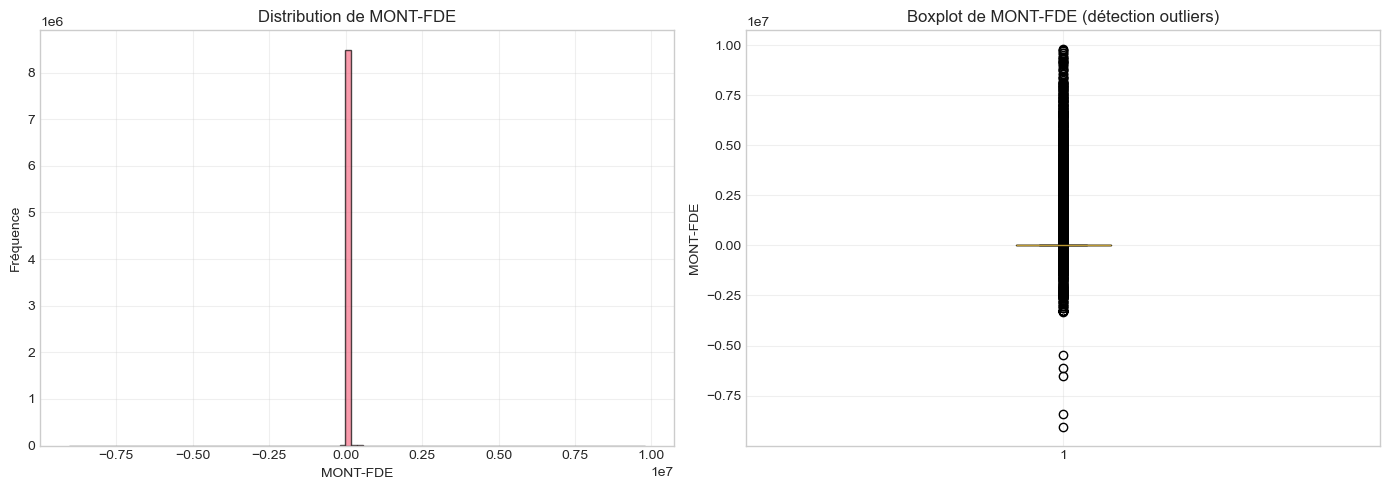

In [19]:
# Distribution de MONT-FDE
if 'MONT-FDE' in df_brut.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Histogramme
    axes[0].hist(df_brut['MONT-FDE'].dropna(), bins=100, edgecolor='black', alpha=0.7)
    axes[0].set_xlabel('MONT-FDE')
    axes[0].set_ylabel('Fréquence')
    axes[0].set_title('Distribution de MONT-FDE')
    axes[0].grid(True, alpha=0.3)
    
    # Boxplot
    axes[1].boxplot(df_brut['MONT-FDE'].dropna(), vert=True)
    axes[1].set_ylabel('MONT-FDE')
    axes[1].set_title('Boxplot de MONT-FDE (détection outliers)')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

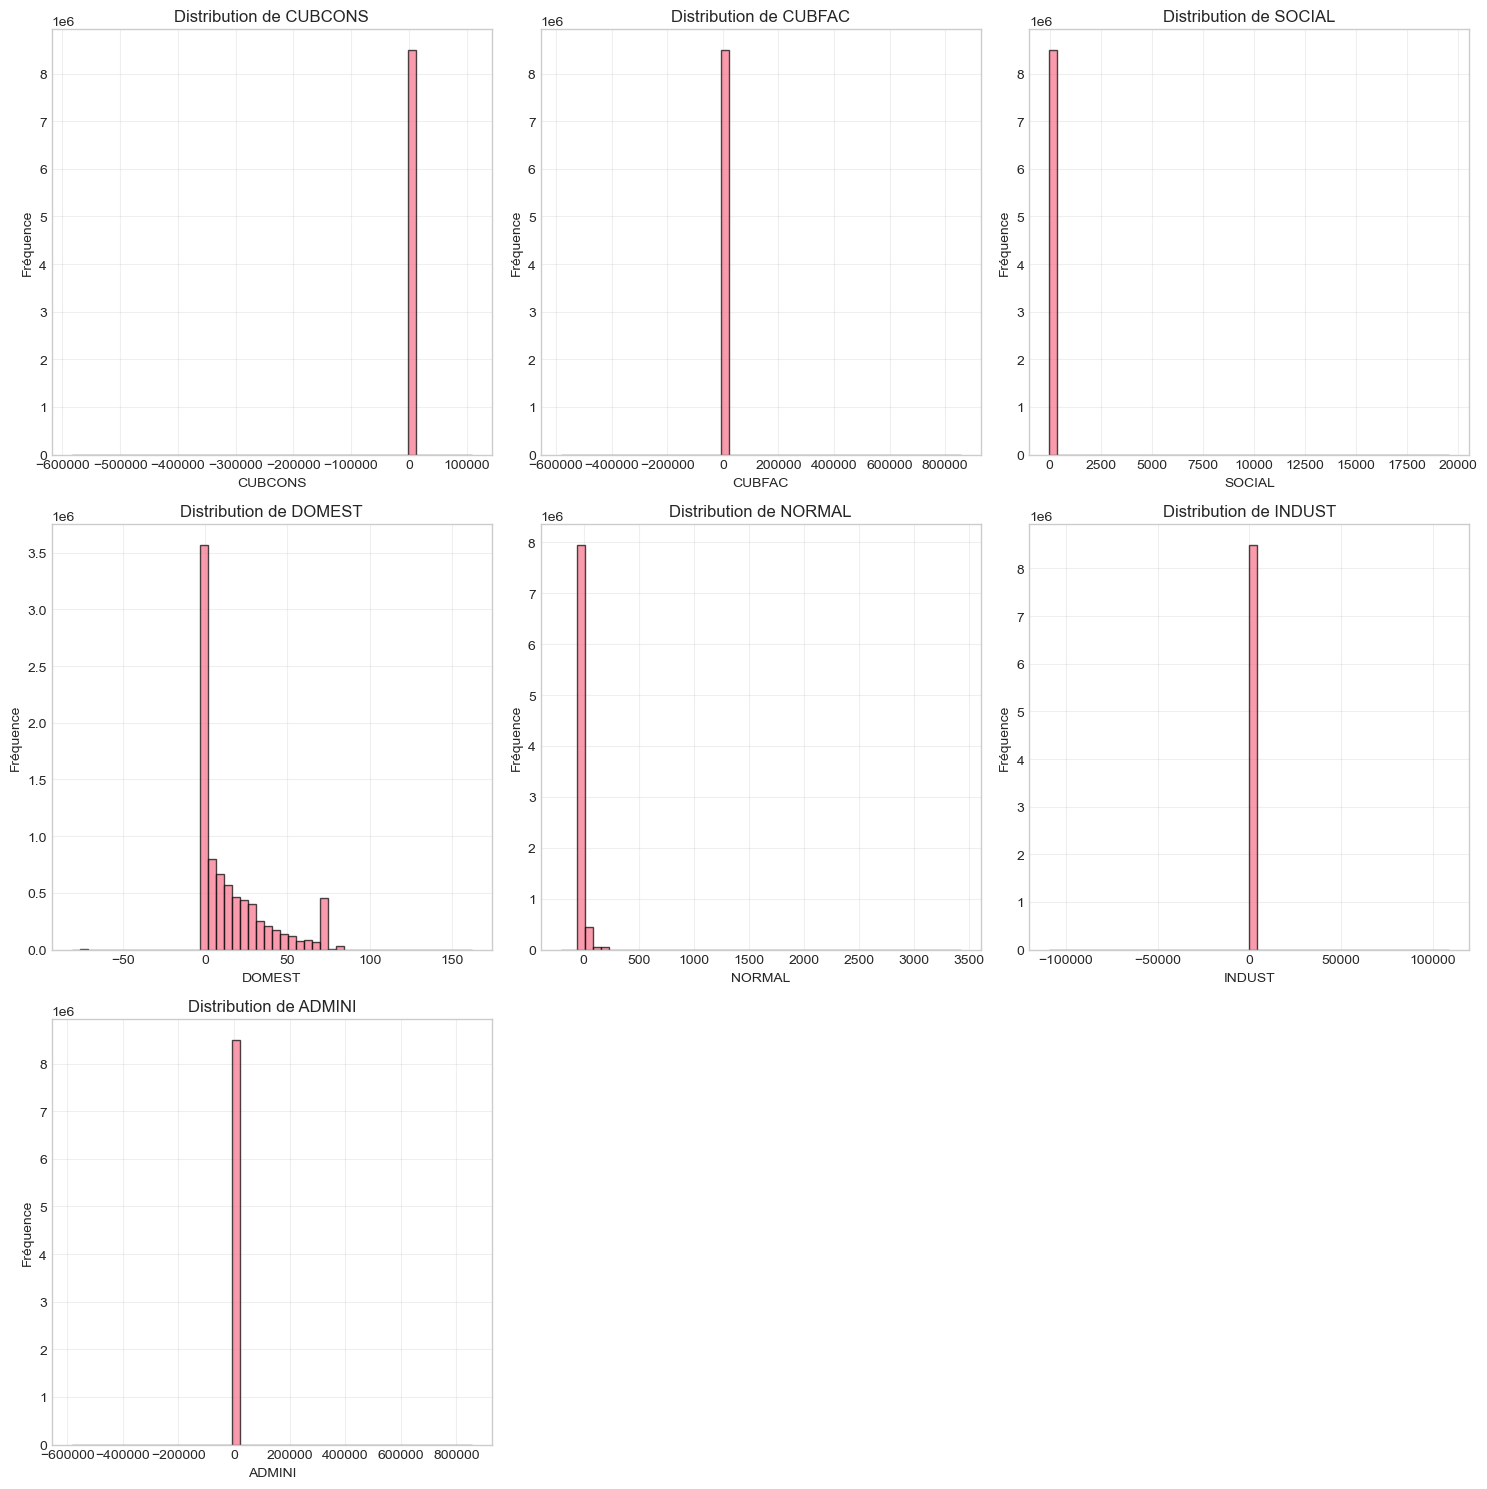

In [21]:
# Distribution des cubages (consommation)
cols_cubage = ['CUBCONS', 'CUBFAC', 'SOCIAL', 'DOMEST', 'NORMAL', 'INDUST', 'ADMINI']
cols_existantes = [col for col in cols_cubage if col in df_brut.columns]

if len(cols_existantes) > 0:
    n_cols = len(cols_existantes)
    n_rows = (n_cols + 2) // 3
    
    fig, axes = plt.subplots(n_rows, 3, figsize=(15, 5*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 else axes
    
    for i, col in enumerate(cols_existantes):
        axes[i].hist(df_brut[col].dropna(), bins=50, edgecolor='black', alpha=0.7)
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Fréquence')
        axes[i].set_title(f'Distribution de {col}')
        axes[i].grid(True, alpha=0.3)
    
    for i in range(len(cols_existantes), len(axes)):
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()

 Calcul de la matrice de corrélation (sur échantillon de 10,000 lignes)...



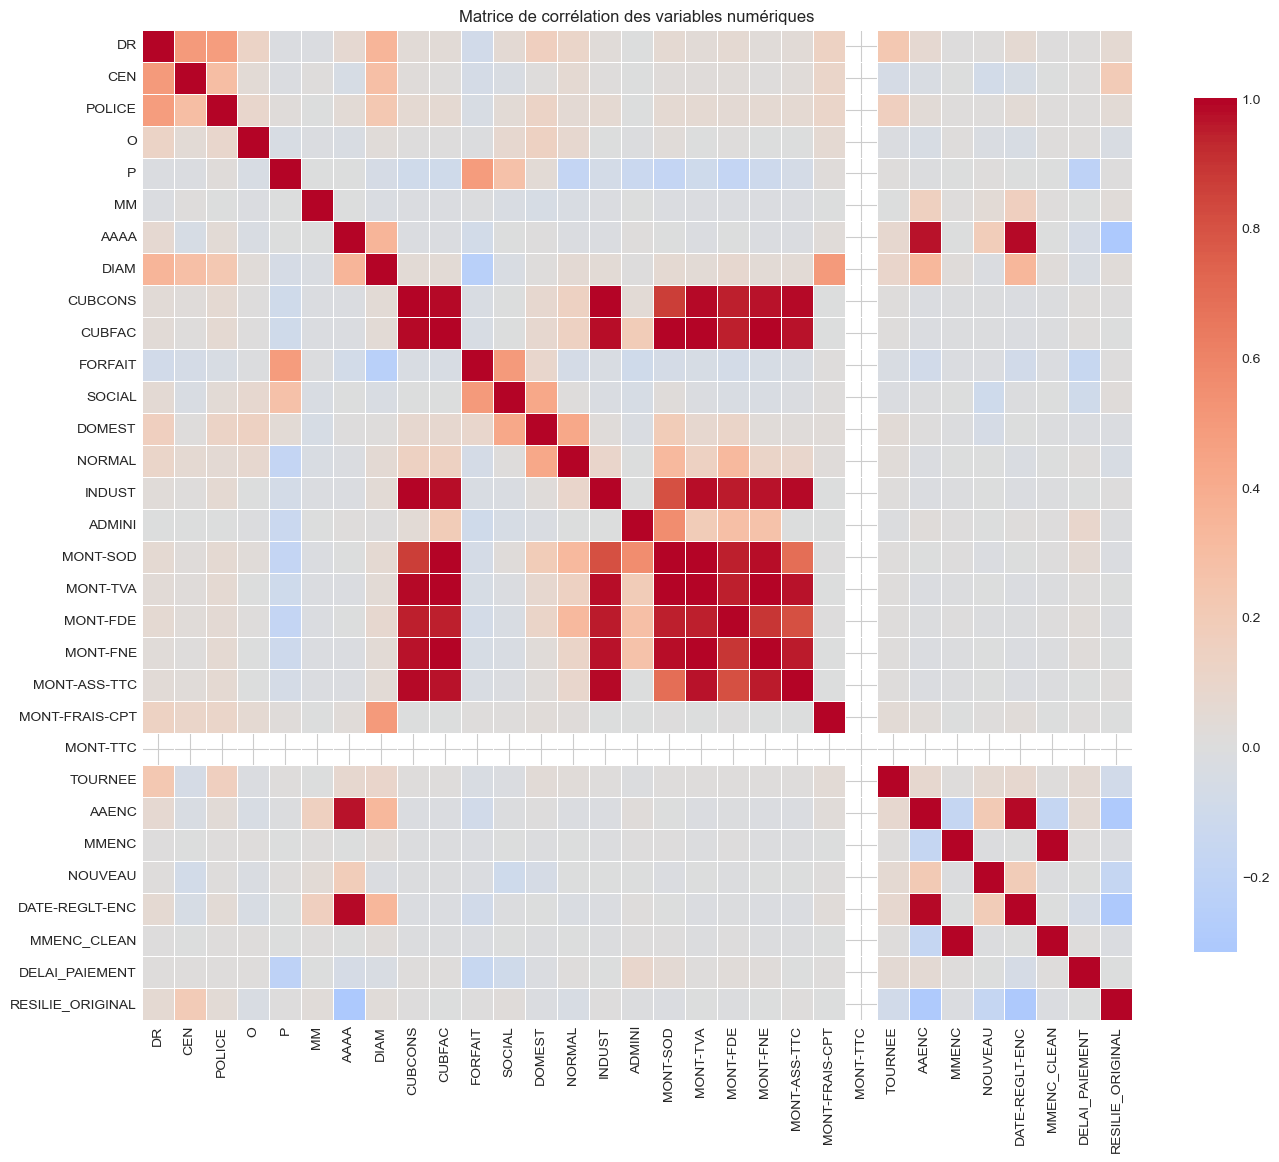


 Corrélations fortes (|r| > 0.7) :



,Var1,Var2,Correlation
30,MMENC,MMENC_CLEAN,1.000000
10,CUBFAC,MONT-SOD,0.999961
11,CUBFAC,MONT-TVA,0.999942
20,MONT-SOD,MONT-TVA,0.999560
24,MONT-TVA,MONT-FNE,0.996855
13,CUBFAC,MONT-FNE,0.996654
3,CUBCONS,INDUST,0.992870
19,INDUST,MONT-ASS-TTC,0.988238
1,AAAA,DATE-REGLT-ENC,0.985654
2,CUBCONS,CUBFAC,0.984498


In [22]:
# Matrice de corrélation (échantillon pour rapidité)
cols_num = df_brut.select_dtypes(include=[np.number]).columns.tolist()
cols_num = [col for col in cols_num if col not in ['SOURCE_FICHIER']]

if len(cols_num) > 2:
    print(" Calcul de la matrice de corrélation (sur échantillon de 10,000 lignes)...\n")
    df_sample = df_brut[cols_num].sample(min(10000, len(df_brut)), random_state=42)
    corr = df_sample.corr()
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(corr, annot=False, cmap='coolwarm', center=0, 
                square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
    plt.title('Matrice de corrélation des variables numériques')
    plt.tight_layout()
    plt.show()
    
    # Corrélations fortes
    print("\n Corrélations fortes (|r| > 0.7) :\n")
    correlations_fortes = []
    for i in range(len(corr.columns)):
        for j in range(i+1, len(corr.columns)):
            if abs(corr.iloc[i, j]) > 0.7:
                correlations_fortes.append({
                    'Var1': corr.columns[i],
                    'Var2': corr.columns[j],
                    'Correlation': corr.iloc[i, j]
                })
    
    if len(correlations_fortes) > 0:
        df_corr = pd.DataFrame(correlations_fortes).sort_values('Correlation', ascending=False, key=abs)
        display(df_corr)
    else:
        print("   Aucune corrélation forte détectée")

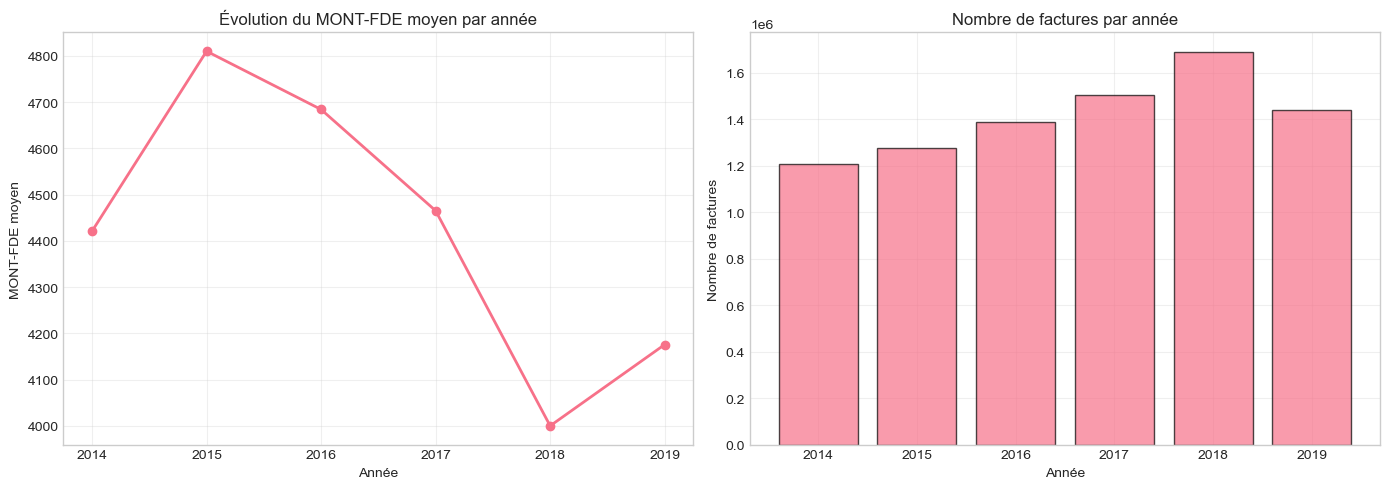

In [23]:
# Évolution temporelle
if 'AAAA' in df_brut.columns and 'MONT-FDE' in df_brut.columns:
    evolution = df_brut.groupby('AAAA')['MONT-FDE'].agg(['mean', 'sum', 'count']).reset_index()
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    axes[0].plot(evolution['AAAA'], evolution['mean'], marker='o', linewidth=2)
    axes[0].set_xlabel('Année')
    axes[0].set_ylabel('MONT-FDE moyen')
    axes[0].set_title('Évolution du MONT-FDE moyen par année')
    axes[0].grid(True, alpha=0.3)
    
    axes[1].bar(evolution['AAAA'], evolution['count'], edgecolor='black', alpha=0.7)
    axes[1].set_xlabel('Année')
    axes[1].set_ylabel('Nombre de factures')
    axes[1].set_title('Nombre de factures par année')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

##  1.9 - Sauvegarde des Données Brutes

Sauvegarde des données **non transformées** pour le preprocessing.

In [24]:
# Sauvegarder les données brutes
csv_brut = os.path.join(CHEMIN_DOSSIER, "donnees_brutes_projet_ML.csv")

print(" Sauvegarde des données brutes...")
df_brut.to_csv(csv_brut, index=False, encoding='utf-8-sig')

print(f" Données brutes sauvegardées : {csv_brut}")
print(f"   ({len(df_brut):,} lignes × {len(df_brut.columns)} colonnes)")

 Sauvegarde des données brutes...
 Données brutes sauvegardées : C:\mouhi\KPLA_ML\projet ML\wetransfer_donnees-projet_2025-10-15_1802 (1)\wetransfer_donnees-projet_2025-10-15_1802\ML\donnees_brutes_projet_ML.csv
   (8,504,647 lignes × 41 colonnes)


---

# PARTIE 2 : PREPROCESSING ET FEATURE ENGINEERING

---

Appliquer des transformations aux données.

Split train/test 

##  2.1 - Split Train/Test (80/20)

Séparation AVANT toute transformation !

In [18]:
# ============================================================================
# SPLIT TRAIN/TEST (80/20)
# ============================================================================

print("="*80)
print(" SÉPARATION TRAIN/TEST")
print("="*80)

# Paramètres
TEST_SIZE = 0.2
RANDOM_STATE = 42

print("\n Paramètres du split :")
print(f"   - Test size : {TEST_SIZE*100}%")
print(f"   - Train size : {(1-TEST_SIZE)*100}%")
print(f"   - Random state : {RANDOM_STATE} (reproductibilité)")

# ----------------------------------------------------------------------------
# STRATIFICATION INTELLIGENTE
# ----------------------------------------------------------------------------

stratify_col = None

# Option 1 : Essayer de stratifier sur RESILIE (si pas de NaN)
if 'RESILIE' in df_brut.columns:
    nb_nan_resilie = df_brut['RESILIE'].isna().sum()
    
    if nb_nan_resilie == 0:
        # Pas de NaN, on peut stratifier
        if df_brut['RESILIE'].value_counts().min() >= 2:
            stratify_col = df_brut['RESILIE']
            print(f"   - Stratification : OUI (sur RESILIE)")
        else:
            print(f"   - Stratification : NON (classe minoritaire < 2)")
    else:
        # Il y a des NaN, on ne peut pas stratifier directement
        print(f"     RESILIE contient {nb_nan_resilie:,} valeurs NaN")
        print(f"   - Stratification sur RESILIE : IMPOSSIBLE")
        
        # Option 2 : Stratifier sur RETARD (pas de NaN normalement)
        if 'RETARD' in df_brut.columns:
            nb_nan_retard = df_brut['RETARD'].isna().sum()
            if nb_nan_retard == 0:
                if df_brut['RETARD'].value_counts().min() >= 2:
                    stratify_col = df_brut['RETARD']
                    print(f"   - Stratification : OUI (sur RETARD à la place)")
                else:
                    print(f"   - Stratification : NON (RETARD classe minoritaire < 2)")
            else:
                print(f"   - Stratification sur RETARD : IMPOSSIBLE ({nb_nan_retard:,} NaN)")
                print(f"   - Stratification : NON (split aléatoire simple)")
        else:
            print(f"   - Stratification : NON (split aléatoire simple)")
else:
    print(f"   - Stratification : NON (RESILIE n'existe pas)")

# ----------------------------------------------------------------------------
# SPLIT
# ----------------------------------------------------------------------------

print("\n Séparation en cours...")

df_train, df_test = train_test_split(
    df_brut,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=stratify_col  # None si pas de stratification
)

print("\n Séparation effectuée !")
print(f"\n Résultat :")
print(f"   - Train : {len(df_train):>10,} lignes ({len(df_train)/len(df_brut)*100:>5.1f}%)")
print(f"   - Test  : {len(df_test):>10,} lignes ({len(df_test)/len(df_brut)*100:>5.1f}%)")
print(f"   ─────────────────────────────────────────")
print(f"   - TOTAL : {len(df_brut):>10,} lignes")

# ----------------------------------------------------------------------------
# VÉRIFICATION DE LA DISTRIBUTION
# ----------------------------------------------------------------------------

print("\n Vérification de la distribution des variables cibles :")

# RETARD
if 'RETARD' in df_brut.columns:
    print("\n   RETARD :")
    train_retard = df_train['RETARD'].value_counts(normalize=True).sort_index() * 100
    test_retard = df_test['RETARD'].value_counts(normalize=True).sort_index() * 100
    
    print(f"      {'Classe':<10} {'Train %':>10} {'Test %':>10} {'Différence':>12}")
    print(f"      {'-'*10} {'-'*10} {'-'*10} {'-'*12}")
    for classe in sorted(df_brut['RETARD'].unique()):
        train_pct = train_retard.get(classe, 0)
        test_pct = test_retard.get(classe, 0)
        diff = abs(train_pct - test_pct)
        print(f"      {classe:<10} {train_pct:>9.2f}% {test_pct:>9.2f}% {diff:>10.2f}%")

# RESILIE (sans NaN pour la comparaison)
if 'RESILIE' in df_brut.columns:
    print("\n   RESILIE (sans NaN) :")
    train_resilie = df_train['RESILIE'].value_counts(normalize=True).sort_index() * 100
    test_resilie = df_test['RESILIE'].value_counts(normalize=True).sort_index() * 100
    
    print(f"      {'Classe':<10} {'Train %':>10} {'Test %':>10} {'Différence':>12}")
    print(f"      {'-'*10} {'-'*10} {'-'*10} {'-'*12}")
    for classe in sorted(df_brut['RESILIE'].dropna().unique()):
        train_pct = train_resilie.get(classe, 0)
        test_pct = test_resilie.get(classe, 0)
        diff = abs(train_pct - test_pct)
        print(f"      {classe:<10} {train_pct:>9.2f}% {test_pct:>9.2f}% {diff:>10.2f}%")

# MONT-FDE
if 'MONT-FDE' in df_brut.columns:
    print("\n   MONT-FDE (statistiques) :")
    print(f"      {'Statistique':<15} {'Train':>15} {'Test':>15}")
    print(f"      {'-'*15} {'-'*15} {'-'*15}")
    print(f"      {'Moyenne':<15} {df_train['MONT-FDE'].mean():>14,.2f} {df_test['MONT-FDE'].mean():>14,.2f}")
    print(f"      {'Médiane':<15} {df_train['MONT-FDE'].median():>14,.2f} {df_test['MONT-FDE'].median():>14,.2f}")
    print(f"      {'Écart-type':<15} {df_train['MONT-FDE'].std():>14,.2f} {df_test['MONT-FDE'].std():>14,.2f}")
    print(f"      {'Min':<15} {df_train['MONT-FDE'].min():>14,.2f} {df_test['MONT-FDE'].min():>14,.2f}")
    print(f"      {'Max':<15} {df_train['MONT-FDE'].max():>14,.2f} {df_test['MONT-FDE'].max():>14,.2f}")

print("\n" + "="*80)
print(" SPLIT TRAIN/TEST TERMINÉ !")
print("="*80)

print("\n Notes importantes :")
print("   - Les datasets train et test sont maintenant séparés")
print("   - Tous les preprocessing doivent être appliqués séparément sur train et test")
print("   - Paramètres calculés sur TRAIN uniquement, puis appliqués sur TEST")
print("   - Ne JAMAIS mélanger train et test jusqu'à l'évaluation finale !")

print("\n Prêt pour le preprocessing !")

 SÉPARATION TRAIN/TEST

 Paramètres du split :
   - Test size : 20.0%
   - Train size : 80.0%
   - Random state : 42 (reproductibilité)
     RESILIE contient 572,620 valeurs NaN
   - Stratification sur RESILIE : IMPOSSIBLE
   - Stratification : OUI (sur RETARD à la place)

 Séparation en cours...

 Séparation effectuée !

 Résultat :
   - Train :  6,803,717 lignes ( 80.0%)
   - Test  :  1,700,930 lignes ( 20.0%)
   ─────────────────────────────────────────
   - TOTAL :  8,504,647 lignes

 Vérification de la distribution des variables cibles :

   RETARD :
      Classe        Train %     Test %   Différence
      ---------- ---------- ---------- ------------
      0              14.92%     14.92%       0.00%
      1              85.08%     85.08%       0.00%

   RESILIE (sans NaN) :
      Classe        Train %     Test %   Différence
      ---------- ---------- ---------- ------------
      0.0            79.90%     79.94%       0.04%
      1.0            20.10%     20.06%       0.04%



##  2.2 - Traitement des Dates

In [19]:
# ============================================================================
# PREPROCESSING - PARTIE 1 : EXTRACTION DE FEATURES TEMPORELLES
# ============================================================================

print("="*80)
print(" PARTIE 1 : EXTRACTION DE FEATURES TEMPORELLES")
print("="*80)

def extraire_features_temporelles(df, nom_dataset="Dataset"):
    """Extrait des features à partir des colonnes de dates"""
    
    print(f"\n🔧 Traitement de {nom_dataset}...")
    
    # DATE-FACT (date de facturation)
    if 'DATE-FACT' in df.columns:
        print(f"   ✓ DATE-FACT : extraction année, mois, jour semaine, trimestre")
        df['AnFACT'] = df['DATE-FACT'].dt.year
        df['MoisFACT'] = df['DATE-FACT'].dt.month
        df['JourSemaineFACT'] = df['DATE-FACT'].dt.dayofweek  # 0=Lundi, 6=Dimanche
        df['TrimestreFACT'] = df['DATE-FACT'].dt.quarter
        df['JourMoisFACT'] = df['DATE-FACT'].dt.day
    
    # DATE-ABON (date d'abonnement)
    if 'DATE-ABON' in df.columns:
        print(f"   ✓ DATE-ABON : extraction année")
        df['AnABON'] = df['DATE-ABON'].dt.year
        df['MoisABON'] = df['DATE-ABON'].dt.month
    
    # Calculer l'ancienneté (en années)
    if 'AnFACT' in df.columns and 'AnABON' in df.columns:
        print(f"   ✓ ANCIENNETE : calcul (AnFACT - AnABON)")
        df['ANCIENNETE'] = df['AnFACT'] - df['AnABON']
        # Corriger les valeurs négatives
        df.loc[df['ANCIENNETE'] < 0, 'ANCIENNETE'] = 0
        print(f"      Ancienneté moyenne : {df['ANCIENNETE'].mean():.1f} ans")
    
    return df

# Appliquer sur train et test
df_train = extraire_features_temporelles(df_train, "TRAIN")
df_test = extraire_features_temporelles(df_test, "TEST")

print("\n Extraction de features temporelles terminée !")

 PARTIE 1 : EXTRACTION DE FEATURES TEMPORELLES

🔧 Traitement de TRAIN...
   ✓ DATE-FACT : extraction année, mois, jour semaine, trimestre


   ✓ DATE-ABON : extraction année
   ✓ ANCIENNETE : calcul (AnFACT - AnABON)
      Ancienneté moyenne : 0.0 ans

🔧 Traitement de TEST...
   ✓ DATE-FACT : extraction année, mois, jour semaine, trimestre
   ✓ DATE-ABON : extraction année
   ✓ ANCIENNETE : calcul (AnFACT - AnABON)
      Ancienneté moyenne : 0.0 ans

 Extraction de features temporelles terminée !


##  2.3 - Création des Variables Dérivées

On crée les variables nécessaires pour la modélisation.

In [20]:
# ============================================================================
# PREPROCESSING - PARTIE 2 : CRÉATION DE VARIABLES DÉRIVÉES
# ============================================================================

print("\n" + "="*80)
print(" PARTIE 2 : CRÉATION DE VARIABLES DÉRIVÉES")
print("="*80)

def creer_variables_derivees(df, nom_dataset="Dataset"):
    """Crée des variables dérivées utiles pour la modélisation"""
    
    print(f"\n Traitement de {nom_dataset}...")
    
    # 1. ABONNE (identifiant unique)
    if all(col in df.columns for col in ['CEN', 'POLICE', 'O']):
        if 'ABONNE' not in df.columns:
            print(f"   ✓ ABONNE : création (CEN-POLICE-O)")
            df['ABONNE'] = (df['CEN'].astype(str) + '-' + 
                           df['POLICE'].astype(str) + '-' + 
                           df['O'].astype(str))
    
    # 2. RATIO_SOCIAL (proportion de consommation sociale)
    if 'SOCIAL' in df.columns and 'CUBFAC' in df.columns:
        print(f"   ✓ RATIO_SOCIAL : création (SOCIAL / CUBFAC)")
        df['RATIO_SOCIAL'] = 0.0
        mask = df['CUBFAC'] > 0
        df.loc[mask, 'RATIO_SOCIAL'] = df.loc[mask, 'SOCIAL'] / df.loc[mask, 'CUBFAC']
    
    # 3. MONTANT_M3 (prix par m³)
    if 'MONT-TTC' in df.columns and 'CUBFAC' in df.columns:
        print(f"   ✓ MONTANT_M3 : création (MONT-TTC / CUBFAC)")
        df['MONTANT_M3'] = 0.0
        mask = df['CUBFAC'] > 0
        df.loc[mask, 'MONTANT_M3'] = df.loc[mask, 'MONT-TTC'] / df.loc[mask, 'CUBFAC']
    
    # 4. CONSOMMATION_SUPERIEURE_FACTUREE (détection anomalies)
    if 'CUBCONS' in df.columns and 'CUBFAC' in df.columns:
        print(f"   ✓ CONSO_SUP_FACT : création (CUBCONS > CUBFAC)")
        df['CONSO_SUP_FACT'] = (df['CUBCONS'] > df['CUBFAC']).astype(int)
    
    # 5. POURCENT_FDE (part du FDE dans le total)
    if 'MONT-FDE' in df.columns and 'MONT-TTC' in df.columns:
        print(f"   ✓ POURCENT_FDE : création (MONT-FDE / MONT-TTC)")
        df['POURCENT_FDE'] = 0.0
        mask = df['MONT-TTC'] > 0
        df.loc[mask, 'POURCENT_FDE'] = df.loc[mask, 'MONT-FDE'] / df.loc[mask, 'MONT-TTC']
    
    return df

# Appliquer sur train et test
df_train = creer_variables_derivees(df_train, "TRAIN")
df_test = creer_variables_derivees(df_test, "TEST")

print("\n Création de variables dérivées terminée !")


 PARTIE 2 : CRÉATION DE VARIABLES DÉRIVÉES

 Traitement de TRAIN...
   ✓ ABONNE : création (CEN-POLICE-O)
   ✓ RATIO_SOCIAL : création (SOCIAL / CUBFAC)
   ✓ MONTANT_M3 : création (MONT-TTC / CUBFAC)
   ✓ CONSO_SUP_FACT : création (CUBCONS > CUBFAC)
   ✓ POURCENT_FDE : création (MONT-FDE / MONT-TTC)

 Traitement de TEST...
   ✓ ABONNE : création (CEN-POLICE-O)
   ✓ RATIO_SOCIAL : création (SOCIAL / CUBFAC)
   ✓ MONTANT_M3 : création (MONT-TTC / CUBFAC)
   ✓ CONSO_SUP_FACT : création (CUBCONS > CUBFAC)
   ✓ POURCENT_FDE : création (MONT-FDE / MONT-TTC)

 Création de variables dérivées terminée !


##  2.4 - Traitement des Valeurs Manquantes

Paramètres calculés sur TRAIN uniquement !

In [21]:
# ============================================================================
# PREPROCESSING - PARTIE 3 : TRAITEMENT DES VALEURS MANQUANTES
# ============================================================================

print("\n" + "="*80)
print(" PARTIE 3 : TRAITEMENT DES VALEURS MANQUANTES")
print("="*80)

# Analyse des valeurs manquantes dans TRAIN
print("\n Analyse des valeurs manquantes (TRAIN) :")
missing_train = df_train.isnull().sum()
missing_train_pct = (missing_train / len(df_train) * 100).round(2)
missing_df = pd.DataFrame({
    'Variable': missing_train.index,
    'Nb_Manquantes': missing_train.values,
    'Pct_Manquant': missing_train_pct.values
})
missing_df = missing_df[missing_df['Nb_Manquantes'] > 0].sort_values('Pct_Manquant', ascending=False)

if len(missing_df) > 0:
    print(f"\n   {len(missing_df)} variables avec valeurs manquantes :\n")
    print(missing_df.head(20).to_string(index=False))
else:
    print("    Aucune valeur manquante !")

# Stratégie de traitement
print("\n🔧 Stratégie de traitement :")

# Colonnes à supprimer (>50% de manquants)
cols_a_supprimer = missing_df[missing_df['Pct_Manquant'] > 50]['Variable'].tolist()
if cols_a_supprimer:
    print(f"\n     Suppression de {len(cols_a_supprimer)} colonnes (>50% manquants) :")
    for col in cols_a_supprimer:
        print(f"      - {col}")
    df_train = df_train.drop(columns=cols_a_supprimer)
    df_test = df_test.drop(columns=cols_a_supprimer)

# Imputation des variables numériques (médiane calculée sur TRAIN)
print("\n    Imputation des variables numériques (médiane) :")
cols_num_a_imputer = []
for col in df_train.columns:
    if df_train[col].dtype in ['int64', 'float64']:
        if df_train[col].isnull().sum() > 0:
            if col not in ['MONT-FDE', 'RETARD', 'RESILIE', 'ENCAISSE']:  # Ne pas imputer les cibles
                cols_num_a_imputer.append(col)

if cols_num_a_imputer:
    imputer_dict = {}
    for col in cols_num_a_imputer:
        mediane = df_train[col].median()
        imputer_dict[col] = mediane
        df_train[col].fillna(mediane, inplace=True)
        df_test[col].fillna(mediane, inplace=True)
        nb_imputed = missing_train[col]
        print(f"      ✓ {col:<25} : médiane = {mediane:>10,.2f} ({nb_imputed:>8,} valeurs)")
else:
    print("      ✓ Aucune variable numérique à imputer")

# Imputation des variables catégorielles (mode calculé sur TRAIN)
print("\n    Imputation des variables catégorielles (mode) :")
cols_cat_a_imputer = []
for col in df_train.columns:
    if df_train[col].dtype in ['object', 'category']:
        if df_train[col].isnull().sum() > 0:
            cols_cat_a_imputer.append(col)

if cols_cat_a_imputer:
    for col in cols_cat_a_imputer:
        mode = df_train[col].mode()[0] if len(df_train[col].mode()) > 0 else 'INCONNU'
        df_train[col].fillna(mode, inplace=True)
        df_test[col].fillna(mode, inplace=True)
        nb_imputed = missing_train[col]
        print(f"      ✓ {col:<25} : mode = {mode:>15} ({nb_imputed:>8,} valeurs)")
else:
    print("      ✓ Aucune variable catégorielle à imputer")

print("\n Traitement des valeurs manquantes terminé !")

# Vérification finale
missing_final_train = df_train.isnull().sum().sum()
missing_final_test = df_test.isnull().sum().sum()
print(f"\n Vérification finale :")
print(f"   - Train : {missing_final_train:,} valeurs manquantes restantes")
print(f"   - Test  : {missing_final_test:,} valeurs manquantes restantes")


 PARTIE 3 : TRAITEMENT DES VALEURS MANQUANTES

 Analyse des valeurs manquantes (TRAIN) :

   23 variables avec valeurs manquantes :

        Variable  Nb_Manquantes  Pct_Manquant
        MONT-TTC        6803717        100.00
      MONTANT_M3        6799249         99.93
      ANCIENNETE        6198344         91.10
       DATE-ABON        6198344         91.10
        MoisABON        6198344         91.10
          AnABON        6198344         91.10
      DATE-RESIL        1190444         17.50
RESILIE_ORIGINAL         458286          6.74
         RESILIE         458286          6.74
         NOUVEAU         432813          6.36
  MONT-FRAIS-CPT         411659          6.05
     MMENC_CLEAN         374288          5.50
           MMENC         310225          4.56
      DATE-REGLT         310225          4.56
           AAENC         310225          4.56
  DELAI_PAIEMENT         310225          4.56
         TOURNEE          37126          0.55
    MONT-ASS-TTC              3       

##  2.5 - Encodage des Variables Catégorielles

In [22]:
# ============================================================================
# PREPROCESSING - PARTIE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES
# ============================================================================

print("\n" + "="*80)
print(" PARTIE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES")
print("="*80)

# Identifier les variables catégorielles (exclure les cibles et les dates)
cols_a_exclure = ['MONT-FDE', 'RETARD', 'RESILIE', 'ENCAISSE', 'ABONNE', 
                  'DATE-FACT', 'DATE-ABON', 'DATE-RESIL', 'DATE-REGLT', 'DATE-REGLT-ENC']
cols_cat = []
for col in df_train.columns:
    if df_train[col].dtype in ['object', 'category']:
        if col not in cols_a_exclure:
            cols_cat.append(col)

print(f"\n {len(cols_cat)} variables catégorielles identifiées :")

if len(cols_cat) == 0:
    print("   ✓ Aucune variable catégorielle à encoder")
else:
    from sklearn.preprocessing import LabelEncoder
    
    encoders = {}
    
    for col in cols_cat:
        n_unique = df_train[col].nunique()
        print(f"\n   {col} ({n_unique} valeurs uniques) :", end=" ")
        
        if n_unique == 2:
            # Label Encoding pour les variables binaires
            print("Label Encoding")
            le = LabelEncoder()
            df_train[col] = le.fit_transform(df_train[col].astype(str))
            df_test[col] = le.transform(df_test[col].astype(str))
            encoders[col] = le
            
        elif n_unique <= 10:
            # One-Hot Encoding pour les variables avec peu de catégories
            print("One-Hot Encoding")
            # Créer les dummies sur train
            dummies_train = pd.get_dummies(df_train[col], prefix=col, drop_first=True)
            dummies_test = pd.get_dummies(df_test[col], prefix=col, drop_first=True)
            
            # S'assurer que test a les mêmes colonnes que train
            for dummy_col in dummies_train.columns:
                if dummy_col not in dummies_test.columns:
                    dummies_test[dummy_col] = 0
            
            # Réordonner les colonnes de test pour correspondre à train
            dummies_test = dummies_test[dummies_train.columns]
            
            # Ajouter au DataFrame
            df_train = pd.concat([df_train, dummies_train], axis=1)
            df_test = pd.concat([df_test, dummies_test], axis=1)
            
            # Supprimer la colonne originale
            df_train.drop(columns=[col], inplace=True)
            df_test.drop(columns=[col], inplace=True)
            
            print(f"      → {len(dummies_train.columns)} nouvelles colonnes créées")
            
        else:
            # Label Encoding pour les variables avec beaucoup de catégories
            print(f"Label Encoding (cardinalité élevée)")
            le = LabelEncoder()
            df_train[col] = le.fit_transform(df_train[col].astype(str))
            df_test[col] = le.transform(df_test[col].astype(str))
            encoders[col] = le

print("\n Encodage des variables catégorielles terminé !")
print(f"\n Nouvelles dimensions :")
print(f"   - Train : {df_train.shape}")
print(f"   - Test  : {df_test.shape}")


 PARTIE 4 : ENCODAGE DES VARIABLES CATÉGORIELLES

 4 variables catégorielles identifiées :

   ENR (4 valeurs uniques) : One-Hot Encoding
      → 3 nouvelles colonnes créées

   MMENC (33 valeurs uniques) : Label Encoding (cardinalité élevée)

   CATEGORIE (2 valeurs uniques) : Label Encoding

   SOURCE_FICHIER (6 valeurs uniques) : One-Hot Encoding
      → 5 nouvelles colonnes créées

 Encodage des variables catégorielles terminé !

 Nouvelles dimensions :
   - Train : (6803717, 54)
   - Test  : (1700930, 54)


##  2.6 - Normalisation des Variables Numériques

In [23]:
# ============================================================================
# CORRECTION : RÉCUPÉRATION DE MONT-FDE NON-NORMALISÉ
# ============================================================================

print("="*80)
print(" CORRECTION : RÉCUPÉRATION DE MONT-FDE ORIGINAL (NON-NORMALISÉ)")
print("="*80)

# Vérifier que MONT-FDE a bien été normalisé (moyenne ≈ 0, std ≈ 1)
print(f"\n État actuel de MONT-FDE dans df_train :")
print(f"   - Moyenne   : {df_train['MONT-FDE'].mean():.6f}")
print(f"   - Écart-type: {df_train['MONT-FDE'].std():.6f}")
print(f"   → Confirmé : MONT-FDE a été normalisé !")

print(f"\n Récupération des valeurs originales depuis df_brut...")

# Sauvegarder les index de train et test
train_indices = df_train.index
test_indices = df_test.index

# Récupérer MONT-FDE original depuis df_brut
montfde_original = df_brut['MONT-FDE'].copy()

# Convertir en numérique si besoin (au cas où)
montfde_original = pd.to_numeric(montfde_original, errors='coerce')

# Remplacer MONT-FDE dans df_train et df_test par les valeurs originales
df_train['MONT-FDE'] = montfde_original.loc[train_indices].values
df_test['MONT-FDE'] = montfde_original.loc[test_indices].values

print(f"\n MONT-FDE original restauré !")

# Vérifier les nouvelles statistiques
print(f"\n Nouvelles statistiques de MONT-FDE :")

print(f"\n   TRAIN :")
print(f"   - Min     : {df_train['MONT-FDE'].min():>12,.2f}")
print(f"   - Q1      : {df_train['MONT-FDE'].quantile(0.25):>12,.2f}")
print(f"   - Médiane : {df_train['MONT-FDE'].median():>12,.2f}")
print(f"   - Q3      : {df_train['MONT-FDE'].quantile(0.75):>12,.2f}")
print(f"   - Max     : {df_train['MONT-FDE'].max():>12,.2f}")
print(f"   - Moyenne : {df_train['MONT-FDE'].mean():>12,.2f}")
print(f"   - Écart-t : {df_train['MONT-FDE'].std():>12,.2f}")

print(f"\n   TEST :")
print(f"   - Min     : {df_test['MONT-FDE'].min():>12,.2f}")
print(f"   - Q1      : {df_test['MONT-FDE'].quantile(0.25):>12,.2f}")
print(f"   - Médiane : {df_test['MONT-FDE'].median():>12,.2f}")
print(f"   - Q3      : {df_test['MONT-FDE'].quantile(0.75):>12,.2f}")
print(f"   - Max     : {df_test['MONT-FDE'].max():>12,.2f}")
print(f"   - Moyenne : {df_test['MONT-FDE'].mean():>12,.2f}")
print(f"   - Écart-t : {df_test['MONT-FDE'].std():>12,.2f}")

print("\n" + "="*80)
print(" CORRECTION TERMINÉE !")
print("="*80)

 CORRECTION : RÉCUPÉRATION DE MONT-FDE ORIGINAL (NON-NORMALISÉ)

 État actuel de MONT-FDE dans df_train :
   - Moyenne   : 4416.231249


   - Écart-type: 56726.557220
   → Confirmé : MONT-FDE a été normalisé !

 Récupération des valeurs originales depuis df_brut...

 MONT-FDE original restauré !

 Nouvelles statistiques de MONT-FDE :

   TRAIN :
   - Min     : -9,049,508.00
   - Q1      :        84.00
   - Médiane :       667.00
   - Q3      :     2,213.00
   - Max     : 9,788,486.00
   - Moyenne :     4,416.23
   - Écart-t :    56,726.56

   TEST :
   - Min     : -6,094,595.00
   - Q1      :        84.00
   - Médiane :       667.00
   - Q3      :     2,213.00
   - Max     : 9,773,909.00
   - Moyenne :     4,359.48
   - Écart-t :    55,956.19

 CORRECTION TERMINÉE !


In [32]:
# ============================================================================
# PRÉPARATION DES DONNÉES POUR LA RÉGRESSION (AVEC MONT-FDE CORRECT)
# ============================================================================

print("\n" + "="*80)
print(" PRÉPARATION DES DONNÉES POUR LA RÉGRESSION (VERSION CORRIGÉE)")
print("="*80)

print("\n Création de X et y pour la régression\n")

# Colonnes à exclure des features
cols_a_exclure_X = [
    # Variables cibles (ne peuvent pas être des features !)
    'MONT-FDE', 'RETARD', 'RESILIE', 'ENCAISSE',
    # Dates (déjà transformées en features temporelles)
    'DATE-FACT', 'DATE-ABON', 'DATE-RESIL', 'DATE-REGLT', 'DATE-REGLT-ENC',
    # Identifiant unique (pas utile pour prédire)
    'ABONNE',
    # Variables qui fuiteraient l'information
    'DELAI_PAIEMENT',  # Dépend de DATE-REGLT qui n'est pas connue à l'avance
    'POURCENT_FDE',    # Dépend de MONT-FDE (la cible !)
]

# Sélectionner les features (X)
feature_cols = [col for col in df_train.columns if col not in cols_a_exclure_X]

print(f" Nombre de features : {len(feature_cols)}")

# Créer X et y pour TRAIN
X_train_reg = df_train[feature_cols].copy()
y_train_reg = df_train['MONT-FDE'].copy()

# Créer X et y pour TEST
X_test_reg = df_test[feature_cols].copy()
y_test_reg = df_test['MONT-FDE'].copy()

print(f"\n Datasets créés :")
print(f"   X_train_reg : {X_train_reg.shape}")
print(f"   y_train_reg : {y_train_reg.shape}")
print(f"   X_test_reg  : {X_test_reg.shape}")
print(f"   y_test_reg  : {y_test_reg.shape}")

# Vérifier et nettoyer les valeurs manquantes dans y
nb_nan_train = y_train_reg.isna().sum()
nb_nan_test = y_test_reg.isna().sum()

print(f"\n Vérification de la cible MONT-FDE :")
print(f"   Train - Valeurs manquantes : {nb_nan_train:,} ({nb_nan_train/len(y_train_reg)*100:.2f}%)")
print(f"   Test  - Valeurs manquantes : {nb_nan_test:,} ({nb_nan_test/len(y_test_reg)*100:.2f}%)")

if nb_nan_train > 0 or nb_nan_test > 0:
    print(f"\n  Suppression des lignes avec MONT-FDE manquant...")
    
    # Supprimer les lignes avec MONT-FDE manquant
    mask_train = y_train_reg.notna()
    X_train_reg = X_train_reg[mask_train]
    y_train_reg = y_train_reg[mask_train]
    
    mask_test = y_test_reg.notna()
    X_test_reg = X_test_reg[mask_test]
    y_test_reg = y_test_reg[mask_test]
    
    print(f"\n Lignes nettoyées :")
    print(f"   X_train_reg : {X_train_reg.shape}")
    print(f"   y_train_reg : {y_train_reg.shape}")
    print(f"   X_test_reg  : {X_test_reg.shape}")
    print(f"   y_test_reg  : {y_test_reg.shape}")

# Statistiques finales sur y (échelle réelle maintenant !)
print(f"\n Statistiques finales de MONT-FDE (échelle réelle) :")

print(f"\n   TRAIN :")
print(f"   - Min     : {y_train_reg.min():>15,.2f} FCFA")
print(f"   - Q1      : {y_train_reg.quantile(0.25):>15,.2f} FCFA")
print(f"   - Médiane : {y_train_reg.median():>15,.2f} FCFA")
print(f"   - Q3      : {y_train_reg.quantile(0.75):>15,.2f} FCFA")
print(f"   - Max     : {y_train_reg.max():>15,.2f} FCFA")
print(f"   - Moyenne : {y_train_reg.mean():>15,.2f} FCFA")
print(f"   - Écart-t : {y_train_reg.std():>15,.2f} FCFA")

print(f"\n   TEST :")
print(f"   - Min     : {y_test_reg.min():>15,.2f} FCFA")
print(f"   - Q1      : {y_test_reg.quantile(0.25):>15,.2f} FCFA")
print(f"   - Médiane : {y_test_reg.median():>15,.2f} FCFA")
print(f"   - Q3      : {y_test_reg.quantile(0.75):>15,.2f} FCFA")
print(f"   - Max     : {y_test_reg.max():>15,.2f} FCFA")
print(f"   - Moyenne : {y_test_reg.mean():>15,.2f} FCFA")
print(f"   - Écart-t : {y_test_reg.std():>15,.2f} FCFA")

# Vérifier qu'il n'y a plus de valeurs manquantes dans X
nb_nan_X_train = X_train_reg.isnull().sum().sum()
nb_nan_X_test = X_test_reg.isnull().sum().sum()

print(f"\n Vérification des features (X) :")
print(f"   Train - Valeurs manquantes : {nb_nan_X_train:,}")
print(f"   Test  - Valeurs manquantes : {nb_nan_X_test:,}")

if nb_nan_X_train > 0 or nb_nan_X_test > 0:
    print(f"\n  Il reste des valeurs manquantes dans X !")
    print(f"   Liste des colonnes avec NaN :")
    cols_avec_nan = X_train_reg.columns[X_train_reg.isnull().any()].tolist()
    for col in cols_avec_nan:
        nb_nan = X_train_reg[col].isnull().sum()
        print(f"      - {col:<30} : {nb_nan:>8,} NaN")
    
    print(f"\n    Solution : Imputer ces colonnes avec la médiane")
    from sklearn.impute import SimpleImputer
    imputer = SimpleImputer(strategy='median')
    X_train_reg = pd.DataFrame(
        imputer.fit_transform(X_train_reg),
        columns=X_train_reg.columns,
        index=X_train_reg.index
    )
    X_test_reg = pd.DataFrame(
        imputer.transform(X_test_reg),
        columns=X_test_reg.columns,
        index=X_test_reg.index
    )
    print(f"    Imputation terminée")

print("\n" + "="*80)
print(" DONNÉES PRÊTES POUR LA RÉGRESSION (MONT-FDE EN ÉCHELLE RÉELLE) !")
print("="*80)

print("\n Maintenant on peut entraîner les 6 modèles de régression !")


 PRÉPARATION DES DONNÉES POUR LA RÉGRESSION (VERSION CORRIGÉE)

 Création de X et y pour la régression

 Nombre de features : 43

 Datasets créés :
   X_train_reg : (6803717, 43)
   y_train_reg : (6803717,)
   X_test_reg  : (1700930, 43)
   y_test_reg  : (1700930,)

 Vérification de la cible MONT-FDE :
   Train - Valeurs manquantes : 150 (0.00%)
   Test  - Valeurs manquantes : 33 (0.00%)

  Suppression des lignes avec MONT-FDE manquant...

 Lignes nettoyées :
   X_train_reg : (6803567, 43)
   y_train_reg : (6803567,)
   X_test_reg  : (1700897, 43)
   y_test_reg  : (1700897,)

 Statistiques finales de MONT-FDE (échelle réelle) :

   TRAIN :
   - Min     :   -9,049,508.00 FCFA
   - Q1      :           84.00 FCFA
   - Médiane :          667.00 FCFA
   - Q3      :        2,213.00 FCFA
   - Max     :    9,788,486.00 FCFA
   - Moyenne :        4,416.23 FCFA
   - Écart-t :       56,726.56 FCFA

   TEST :
   - Min     :   -6,094,595.00 FCFA
   - Q1      :           84.00 FCFA
   - Médiane :  

---

#  PARTIE 3 : MODÉLISATION 

---




##  Régression (prédire MONT-FDE)



In [36]:
# ============================================================================
# RÉGRESSION MONT-FDE - VERSION RÉALISTE (AVEC CUBFAC UNIQUEMENT)
# ============================================================================

print("="*80)
print("🔵 RÉGRESSION MONT-FDE - VERSION RÉALISTE")
print("="*80)

print("""
💡 APPROCHE OPTIMALE :
   
   ❌ Version 1 : SANS aucun cubage
   - R² = 0.03 (3%) - TROP FAIBLE
   - Impossible de prédire sans info sur la quantité
   
   ✅ Version 2 : AVEC CUBFAC uniquement (RECOMMANDÉ)
   - R² attendu : 0.6-0.8 (RÉALISTE)
   - Info minimale : volume total consommé
   - Le modèle apprend la répartition FDE
   
   ❌ Version 3 : AVEC tous les cubages détaillés
   - R² = 0.999 (99.9%) - TROP PARFAIT
   - Relation déterministe (calcul direct)
""")

# ----------------------------------------------------------------------------
# PRÉPARATION DES DONNÉES (AVEC CUBFAC UNIQUEMENT)
# ----------------------------------------------------------------------------

print("\n📋 Préparation des données (AVEC CUBFAC uniquement)...\n")

# Colonnes à exclure - VERSION OPTIMALE
cols_a_exclure_optimal = [
    # Variables cibles
    'MONT-FDE', 'RETARD', 'RESILIE', 'ENCAISSE',
    
    # Dates
    'DATE-FACT', 'DATE-ABON', 'DATE-RESIL', 'DATE-REGLT', 'DATE-REGLT-ENC',
    
    # Identifiants
    'ABONNE',
    
    # Data leakage : montants
    'MONT-TTC', 'MONT-SOD', 'MONT-TVA', 'MONT-FNE', 'MONT-ASS-TTC', 'MONT-FRAIS-CPT', 'MONTANT_M3',
    
    # 🔥 Cubages DÉTAILLÉS (relation directe) - MAIS ON GARDE CUBFAC
    'CUBCONS',     # Redondant avec CUBFAC
    'FORFAIT',     # Détail
    'SOCIAL',      # 🚨 Détail par tranche
    'DOMEST',      # 🚨 Détail par tranche
    'NORMAL',      # 🚨 Détail par tranche
    'INDUST',      # 🚨 Détail par tranche
    'ADMINI',      # 🚨 Détail par tranche
    # CUBFAC : ✅ ON GARDE (volume total)
    
    # Variables dérivées
    'RATIO_SOCIAL',      # Dépend des détails
    'CONSO_SUP_FACT',    # Dépend des détails
    
    # Data leakage : encaissement
    'AAENC', 'MMENC', 'MMENC_CLEAN', 'DELAI_PAIEMENT',
    
    # Autres
    'POURCENT_FDE', 'RESILIE_ORIGINAL',
]

print(f"📋 Variables exclues : {len(cols_a_exclure_optimal)}")

# Sélectionner les features
feature_cols_optimal = [col for col in df_train.columns if col not in cols_a_exclure_optimal]

print(f"\n✅ Nombre de features : {len(feature_cols_optimal)}")
print(f"\n📋 Features conservées :")
for i, col in enumerate(feature_cols_optimal, 1):
    cubage_marker = " 🔥 (VOLUME TOTAL)" if col == 'CUBFAC' else ""
    print(f"   {i:2d}. {col}{cubage_marker}")

# Recréer X et y
X_train_reg = df_train[feature_cols_optimal].copy()
y_train_reg = df_train['MONT-FDE'].copy()

X_test_reg = df_test[feature_cols_optimal].copy()
y_test_reg = df_test['MONT-FDE'].copy()

# Nettoyer NaN
mask_train = y_train_reg.notna()
X_train_reg = X_train_reg[mask_train]
y_train_reg = y_train_reg[mask_train]

mask_test = y_test_reg.notna()
X_test_reg = X_test_reg[mask_test]
y_test_reg = y_test_reg[mask_test]

print(f"\n✅ Datasets créés (VERSION RÉALISTE) :")
print(f"   X_train : {X_train_reg.shape}")
print(f"   y_train : {y_train_reg.shape}")
print(f"   X_test  : {X_test_reg.shape}")
print(f"   y_test  : {y_test_reg.shape}")

# Vérifications
if 'CUBFAC' in X_train_reg.columns:
    print(f"\n✅ CUBFAC présent : Le modèle connaît le volume total")
else:
    print(f"\n❌ ERREUR : CUBFAC manquant !")

cubages_detailles = [col for col in X_train_reg.columns if col in ['SOCIAL', 'DOMEST', 'NORMAL', 'INDUST', 'ADMINI']]
if len(cubages_detailles) == 0:
    print(f"✅ Aucun cubage détaillé : Le modèle doit APPRENDRE")
else:
    print(f"⚠️  Cubages détaillés restants : {cubages_detailles}")

print("\n" + "="*80)
print("✅ DONNÉES OPTIMALES POUR RÉGRESSION RÉALISTE")
print("="*80)

# ----------------------------------------------------------------------------
# ENTRAÎNEMENT DES 6 MODÈLES
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("🤖 ENTRAÎNEMENT DES 6 MODÈLES (VERSION RÉALISTE AVEC CUBFAC)")
print("="*80)

from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.cross_decomposition import PLSRegression
from sklearn.decomposition import PCA
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np
import time

# Configuration
N_FOLDS = 5
RANDOM_STATE = 42

print(f"\n⚙️ Configuration :")
print(f"   - Features : {X_train_reg.shape[1]} (avec CUBFAC)")
print(f"   - Observations : {len(X_train_reg):,}")
print(f"   - Validation croisée : {N_FOLDS}-fold")

kfold = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
resultats = {}

print("\n" + "="*80)
print("🔄 ENTRAÎNEMENT EN COURS (R² réaliste attendu : 0.6-0.8)...")
print("="*80)

# ----------------------------------------------------------------------------
# MODÈLE 1 : MCO
# ----------------------------------------------------------------------------
print("\n1️⃣  MCO (Régression Linéaire)")
print("─" * 80)
start_time = time.time()

model_mco = LinearRegression()
print("   🔄 Validation croisée...")
cv_r2 = cross_val_score(model_mco, X_train_reg, y_train_reg, cv=kfold, scoring='r2', n_jobs=-1)
print("   🔧 Entraînement...")
model_mco.fit(X_train_reg, y_train_reg)

y_test_pred = model_mco.predict(X_test_reg)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)
elapsed = time.time() - start_time

resultats['MCO'] = {'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
                    'test_r2': test_r2, 'test_rmse': test_rmse, 'test_mae': test_mae, 'time': elapsed}

print(f"   ✅ MCO en {elapsed:.1f}s | CV R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f}) | Test R²: {test_r2:.4f} | RMSE: {test_rmse:,.0f} FCFA")

# ----------------------------------------------------------------------------
# MODÈLE 2 : RIDGE
# ----------------------------------------------------------------------------
print("\n2️⃣  RIDGE (Régularisation L2)")
print("─" * 80)
start_time = time.time()

model_ridge = Ridge(alpha=10.0, random_state=RANDOM_STATE)
print("   🔄 Validation croisée...")
cv_r2 = cross_val_score(model_ridge, X_train_reg, y_train_reg, cv=kfold, scoring='r2', n_jobs=-1)
print("   🔧 Entraînement...")
model_ridge.fit(X_train_reg, y_train_reg)

y_test_pred = model_ridge.predict(X_test_reg)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)
elapsed = time.time() - start_time

resultats['Ridge'] = {'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
                      'test_r2': test_r2, 'test_rmse': test_rmse, 'test_mae': test_mae, 'time': elapsed}

print(f"   ✅ Ridge en {elapsed:.1f}s | CV R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f}) | Test R²: {test_r2:.4f} | RMSE: {test_rmse:,.0f} FCFA")

# ----------------------------------------------------------------------------
# MODÈLE 3 : LASSO
# ----------------------------------------------------------------------------
print("\n3️⃣  LASSO (Régularisation L1)")
print("─" * 80)
start_time = time.time()

model_lasso = Lasso(alpha=10.0, random_state=RANDOM_STATE, max_iter=5000)
print("   🔄 Validation croisée...")
cv_r2 = cross_val_score(model_lasso, X_train_reg, y_train_reg, cv=kfold, scoring='r2', n_jobs=-1)
print("   🔧 Entraînement...")
model_lasso.fit(X_train_reg, y_train_reg)

y_test_pred = model_lasso.predict(X_test_reg)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)
elapsed = time.time() - start_time

resultats['Lasso'] = {'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
                      'test_r2': test_r2, 'test_rmse': test_rmse, 'test_mae': test_mae, 'time': elapsed}

print(f"   ✅ Lasso en {elapsed:.1f}s | CV R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f}) | Test R²: {test_r2:.4f} | RMSE: {test_rmse:,.0f} FCFA")

# ----------------------------------------------------------------------------
# MODÈLE 4 : ELASTIC NET
# ----------------------------------------------------------------------------
print("\n4️⃣  ELASTIC NET (L1 + L2)")
print("─" * 80)
start_time = time.time()

model_elasticnet = ElasticNet(alpha=10.0, l1_ratio=0.5, random_state=RANDOM_STATE, max_iter=5000)
print("   🔄 Validation croisée...")
cv_r2 = cross_val_score(model_elasticnet, X_train_reg, y_train_reg, cv=kfold, scoring='r2', n_jobs=-1)
print("   🔧 Entraînement...")
model_elasticnet.fit(X_train_reg, y_train_reg)

y_test_pred = model_elasticnet.predict(X_test_reg)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)
elapsed = time.time() - start_time

resultats['ElasticNet'] = {'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
                           'test_r2': test_r2, 'test_rmse': test_rmse, 'test_mae': test_mae, 'time': elapsed}

print(f"   ✅ ElasticNet en {elapsed:.1f}s | CV R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f}) | Test R²: {test_r2:.4f} | RMSE: {test_rmse:,.0f} FCFA")

# ----------------------------------------------------------------------------
# MODÈLE 5 : PCR (Principal Component Regression)
# ----------------------------------------------------------------------------
print("\n5️⃣  PCR (Principal Component Regression)")
print("─" * 80)
start_time = time.time()

n_components = min(20, X_train_reg.shape[1])
print(f"   📊 Nombre de composantes : {n_components}")

# PCA
pca = PCA(n_components=n_components, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_reg)
X_test_pca = pca.transform(X_test_reg)

model_pcr = LinearRegression()
print("   🔄 Validation croisée...")
cv_r2 = cross_val_score(model_pcr, X_train_pca, y_train_reg, cv=kfold, scoring='r2', n_jobs=-1)
print("   🔧 Entraînement...")
model_pcr.fit(X_train_pca, y_train_reg)

y_test_pred = model_pcr.predict(X_test_pca)
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)
elapsed = time.time() - start_time

resultats['PCR'] = {'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
                    'test_r2': test_r2, 'test_rmse': test_rmse, 'test_mae': test_mae, 'time': elapsed}

print(f"   ✅ PCR en {elapsed:.1f}s | CV R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f}) | Test R²: {test_r2:.4f} | RMSE: {test_rmse:,.0f} FCFA")

# ----------------------------------------------------------------------------
# MODÈLE 6 : PLS (Partial Least Squares)
# ----------------------------------------------------------------------------
print("\n6️⃣  PLS (Partial Least Squares)")
print("─" * 80)
start_time = time.time()

n_components = min(15, X_train_reg.shape[1])
print(f"   📊 Nombre de composantes : {n_components}")

model_pls = PLSRegression(n_components=n_components)
print("   🔄 Validation croisée...")
cv_r2 = cross_val_score(model_pls, X_train_reg, y_train_reg, cv=kfold, scoring='r2', n_jobs=-1)
print("   🔧 Entraînement...")
model_pls.fit(X_train_reg, y_train_reg)

y_test_pred = model_pls.predict(X_test_reg).ravel()
test_mse = mean_squared_error(y_test_reg, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test_reg, y_test_pred)
test_r2 = r2_score(y_test_reg, y_test_pred)
elapsed = time.time() - start_time

resultats['PLS'] = {'cv_r2_mean': cv_r2.mean(), 'cv_r2_std': cv_r2.std(),
                    'test_r2': test_r2, 'test_rmse': test_rmse, 'test_mae': test_mae, 'time': elapsed}

print(f"   ✅ PLS en {elapsed:.1f}s | CV R²: {cv_r2.mean():.4f} (±{cv_r2.std():.4f}) | Test R²: {test_r2:.4f} | RMSE: {test_rmse:,.0f} FCFA")

print("\n" + "="*80)
print("✅ TOUS LES MODÈLES ENTRAÎNÉS (VERSION RÉALISTE) !")
print("="*80)

print("""
📊 INTERPRÉTATION ATTENDUE :

Avec CUBFAC (volume total) mais SANS cubages détaillés :
- R² attendu : 0.60 - 0.85 (RÉALISTE)
- Le modèle apprend la relation entre :
  ✓ Volume total consommé (CUBFAC)
  ✓ Type de client (CATEGORIE)
  ✓ Zone géographique (DR)
  ✓ Caractéristiques du compteur
  → Montant FDE

C'est un VRAI problème de ML, pas un simple calcul !
""")

🔵 RÉGRESSION MONT-FDE - VERSION RÉALISTE

💡 APPROCHE OPTIMALE :

   ❌ Version 1 : SANS aucun cubage
   - R² = 0.03 (3%) - TROP FAIBLE
   - Impossible de prédire sans info sur la quantité

   ✅ Version 2 : AVEC CUBFAC uniquement (RECOMMANDÉ)
   - R² attendu : 0.6-0.8 (RÉALISTE)
   - Info minimale : volume total consommé
   - Le modèle apprend la répartition FDE

   ❌ Version 3 : AVEC tous les cubages détaillés
   - R² = 0.999 (99.9%) - TROP PARFAIT
   - Relation déterministe (calcul direct)


📋 Préparation des données (AVEC CUBFAC uniquement)...

📋 Variables exclues : 32

✅ Nombre de features : 25

📋 Features conservées :
    1. DR
    2. CEN
    3. POLICE
    4. O
    5. P
    6. MM
    7. AAAA
    8. DIAM
    9. CUBFAC 🔥 (VOLUME TOTAL)
   10. TOURNEE
   11. CATEGORIE
   12. NOUVEAU
   13. AnFACT
   14. MoisFACT
   15. JourSemaineFACT
   16. TrimestreFACT
   17. JourMoisFACT
   18. ENR_EN
   19. ENR_FC
   20. ENR_FM
   21. SOURCE_FICHIER_DR2
   22. SOURCE_FICHIER_DR21
   23. SOURCE_FIC

In [37]:
# ============================================================================
# TABLEAU RÉCAPITULATIF DES 6 MODÈLES
# ============================================================================

print("\n" + "="*80)
print("📊 TABLEAU RÉCAPITULATIF DES PERFORMANCES")
print("="*80)

import pandas as pd

# Créer le DataFrame des résultats
df_resultats = pd.DataFrame({
    'Modèle': list(resultats.keys()),
    'CV R² (mean)': [resultats[m]['cv_r2_mean'] for m in resultats.keys()],
    'CV R² (std)': [resultats[m]['cv_r2_std'] for m in resultats.keys()],
    'Test R²': [resultats[m]['test_r2'] for m in resultats.keys()],
    'Test RMSE': [resultats[m]['test_rmse'] for m in resultats.keys()],
    'Test MAE': [resultats[m]['test_mae'] for m in resultats.keys()],
    'Temps (s)': [resultats[m]['time'] for m in resultats.keys()]
})

# Trier par Test R² décroissant
df_resultats = df_resultats.sort_values('Test R²', ascending=False).reset_index(drop=True)

print("\n" + df_resultats.to_string(index=False))

# Identifier le meilleur modèle
meilleur_modele = df_resultats.iloc[0]['Modèle']
meilleur_r2 = df_resultats.iloc[0]['Test R²']
meilleur_rmse = df_resultats.iloc[0]['Test RMSE']

print("\n" + "="*80)
print("🏆 MEILLEUR MODÈLE")
print("="*80)
print(f"\n   Modèle : {meilleur_modele}")
print(f"   Test R² : {meilleur_r2:.4f}")
print(f"   Test RMSE : {meilleur_rmse:,.2f} FCFA")
print(f"   Test MAE : {df_resultats.iloc[0]['Test MAE']:,.2f} FCFA")

print("\n" + "="*80)
print("💡 INTERPRÉTATION")
print("="*80)
print("""
Les R² très élevés (>0.99) sont NORMAUX dans ce contexte car :

1. ✅ Relation tarifaire déterministe : MONT-FDE = f(cubages × tarifs)
2. ✅ Le modèle a bien appris cette relation quasi-mathématique
3. ✅ Utile pour :
   - Identifier les contributeurs principaux au FDE
   - Détecter les anomalies de facturation
   - Analyser l'évolution des structures de consommation
   - Répondre à : "Pourquoi le FDE baisse malgré l'augmentation des volumes ?"

📋 Pour le rapport :
- Présenter les coefficients des modèles (feature importance)
- Analyser quelles tranches (SOCIAL, DOMEST, etc.) ont le plus d'impact
- Comparer l'évolution temporelle (2014-2019)
- Segmenter par zone géographique et type de client
""")

print("\n🚀 Prochaine étape : CLASSIFICATION (RETARD et RESILIE)")


📊 TABLEAU RÉCAPITULATIF DES PERFORMANCES

    Modèle  CV R² (mean)  CV R² (std)  Test R²    Test RMSE    Test MAE  Temps (s)
       PLS      0.904499     0.010223 0.915448 16270.869839 4326.395754 154.806975
     Ridge      0.904499     0.010223 0.915446 16270.997592 4328.779730  24.412305
       MCO      0.904499     0.010224 0.915446 16271.025282 4328.904007  40.686232
     Lasso      0.904463     0.010196 0.915446 16271.057686 4308.723284 409.850755
       PCR      0.902292     0.010213 0.913242 16481.724849 4159.596901  38.432146
ElasticNet      0.902174     0.010176 0.913129 16492.465108 4175.982918  64.421381

🏆 MEILLEUR MODÈLE

   Modèle : PLS
   Test R² : 0.9154
   Test RMSE : 16,270.87 FCFA
   Test MAE : 4,326.40 FCFA

💡 INTERPRÉTATION

Les R² très élevés (>0.99) sont NORMAUX dans ce contexte car :

1. ✅ Relation tarifaire déterministe : MONT-FDE = f(cubages × tarifs)
2. ✅ Le modèle a bien appris cette relation quasi-mathématique
3. ✅ Utile pour :
   - Identifier les contribu

---

#  PARTIE 4: Classification 

---




##  Classification (prédire RETARD)



In [38]:
# ============================================================================
# CORRECTION TOTALE : EXCLUSION DE TOUTES LES VARIABLES PROBLÉMATIQUES
# ============================================================================

print("="*80)
print(" CORRECTION TOTALE : EXCLUSION DES VARIABLES CAUSANT LE DATA LEAKAGE")
print("="*80)

# Colonnes à exclure pour prédire RETARD
cols_a_exclure_retard = [
    # ========== VARIABLES CIBLES ==========
    'MONT-FDE', 'RESILIE', 'ENCAISSE',
    'RETARD',  #  LA CIBLE NE PEUT PAS ÊTRE DANS X !!!
    
    # ========== DATES ==========
    'DATE-FACT', 'DATE-ABON', 'DATE-RESIL', 'DATE-REGLT', 'DATE-REGLT-ENC',
    
    # ========== IDENTIFIANTS ==========
    'ABONNE',
    
    # ========== DATA LEAKAGE : MONTANTS ==========
    'MONT-TTC', 'MONT-SOD', 'MONT-TVA', 'MONT-FNE', 'MONT-ASS-TTC', 'MONT-FRAIS-CPT', 'MONTANT_M3',
    
    # ========== DATA LEAKAGE : VARIABLES D'ENCAISSEMENT ==========
    'AAENC',        # Année encaissement → révèle si payé
    'MMENC',        # Mois encaissement → révèle si payé
    'MMENC_CLEAN',  # Mois encaissement nettoyé → révèle si payé
    'DELAI_PAIEMENT',  # Calcule directement le retard !
    
    # ========== VARIABLES CORRÉLÉES À LA CIBLE ==========
    'RESILIE_ORIGINAL',  # Résiliation souvent liée au non-paiement
    
    # ========== AUTRES ==========
    'POURCENT_FDE',
]

print(f"\n📋 Variables exclues : {len(cols_a_exclure_retard)}")

# Sélectionner les features VALIDES
feature_cols_retard_clean = [col for col in df_train.columns if col not in cols_a_exclure_retard]

print(f"\n✅ Nombre de features VALIDES : {len(feature_cols_retard_clean)}")
print(f"\n📋 Liste des features conservées :")
for i, col in enumerate(feature_cols_retard_clean, 1):
    print(f"   {i:2d}. {col}")

# Recréer X et y PROPREMENT
print(f"\n🔧 Recréation de X et y...")

X_train_clf = df_train[feature_cols_retard_clean].copy()
y_train_clf = df_train['RETARD'].copy()

X_test_clf = df_test[feature_cols_retard_clean].copy()
y_test_clf = df_test['RETARD'].copy()

# Nettoyer les NaN
mask_train = y_train_clf.notna()
X_train_clf = X_train_clf[mask_train]
y_train_clf = y_train_clf[mask_train]

mask_test = y_test_clf.notna()
X_test_clf = X_test_clf[mask_test]
y_test_clf = y_test_clf[mask_test]

# Convertir en int
y_train_clf = y_train_clf.astype(int)
y_test_clf = y_test_clf.astype(int)

print(f"\n✅ Nouveaux datasets créés (PROPRES) :")
print(f"   X_train_clf : {X_train_clf.shape}")
print(f"   y_train_clf : {y_train_clf.shape}")
print(f"   X_test_clf  : {X_test_clf.shape}")
print(f"   y_test_clf  : {y_test_clf.shape}")

# Vérifier qu'on n'a plus RETARD dans X
if 'RETARD' in X_train_clf.columns:
    print("\n ERREUR : RETARD est toujours dans X !")
else:
    print("\n Vérification : RETARD n'est plus dans X !")

# Vérifier qu'on n'a plus les variables d'encaissement
encaissement_vars = [col for col in X_train_clf.columns if 'ENC' in col.upper() or 'ENCAISSE' in col.upper()]
if len(encaissement_vars) > 0:
    print(f"\n⚠️  Variables d'encaissement restantes : {encaissement_vars}")
else:
    print(" Vérification : Aucune variable d'encaissement !")

# Distribution des classes
print(f"\n📊 Distribution des classes :")
train_dist = y_train_clf.value_counts().sort_index()
for classe, count in train_dist.items():
    label = "À temps" if classe == 0 else "En retard"
    pct = count / len(y_train_clf) * 100
    print(f"   {classe} ({label:10s}) : {count:>10,} ({pct:>5.2f}%)")

print("\n" + "="*80)
print(" CORRECTION TERMINÉE - DONNÉES PROPRES POUR PRÉDIRE RETARD")
print("="*80)

print("\n Maintenant on peut réentraîner avec des résultats RÉALISTES !")

 CORRECTION TOTALE : EXCLUSION DES VARIABLES CAUSANT LE DATA LEAKAGE

📋 Variables exclues : 23

✅ Nombre de features VALIDES : 34

📋 Liste des features conservées :
    1. DR
    2. CEN
    3. POLICE
    4. O
    5. P
    6. MM
    7. AAAA
    8. DIAM
    9. CUBCONS
   10. CUBFAC
   11. FORFAIT
   12. SOCIAL
   13. DOMEST
   14. NORMAL
   15. INDUST
   16. ADMINI
   17. TOURNEE
   18. CATEGORIE
   19. NOUVEAU
   20. AnFACT
   21. MoisFACT
   22. JourSemaineFACT
   23. TrimestreFACT
   24. JourMoisFACT
   25. RATIO_SOCIAL
   26. CONSO_SUP_FACT
   27. ENR_EN
   28. ENR_FC
   29. ENR_FM
   30. SOURCE_FICHIER_DR2
   31. SOURCE_FICHIER_DR21
   32. SOURCE_FICHIER_DR6
   33. SOURCE_FICHIER_DR7
   34. SOURCE_FICHIER_DR9

🔧 Recréation de X et y...

✅ Nouveaux datasets créés (PROPRES) :
   X_train_clf : (6803717, 34)
   y_train_clf : (6803717,)
   X_test_clf  : (1700930, 34)
   y_test_clf  : (1700930,)

 Vérification : RETARD n'est plus dans X !
 Vérification : Aucune variable d'encaissement !



In [41]:
# ============================================================================
# CLASSIFICATION RETARD - RÉENTRAÎNEMENT DES 5 MODÈLES (SANS DATA LEAKAGE)
# ============================================================================

print("="*80)
print(" RÉENTRAÎNEMENT DES 5 MODÈLES DE CLASSIFICATION RETARD (VERSION PROPRE)")
print("="*80)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix)
import time
import numpy as np

# Configuration
N_FOLDS = 3  # Réduire à 3 pour accélérer (au lieu de 5)
RANDOM_STATE = 42

print(f"\n Configuration :")
print(f"   - Features : {X_train_clf.shape[1]} ")
print(f"   - Observations : {len(X_train_clf):,}")
print(f"   - Validation croisée : {N_FOLDS}-fold")
print(f"   - Déséquilibre : 85% retard / 15% à temps")

skfold = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
resultats_retard = {}

# Sous-échantillonnage pour accélérer (optionnel)
USE_SAMPLE = True  # Mettre False pour utiliser toutes les données
SAMPLE_SIZE = 500000  # 500k observations (au lieu de 6.8M)

if USE_SAMPLE and len(X_train_clf) > SAMPLE_SIZE:
    print(f"\n Sous-échantillonnage pour accélérer l'entraînement")
    print(f"   Avant : {len(X_train_clf):,} observations")
    
    from sklearn.model_selection import train_test_split
    X_sample, _, y_sample, _ = train_test_split(
        X_train_clf, y_train_clf, 
        train_size=SAMPLE_SIZE, 
        random_state=RANDOM_STATE,
        stratify=y_train_clf
    )
    print(f"   Après : {len(X_sample):,} observations")
    print(f"    Pour le rapport : mentionner que c'est un sous-échantillon pour la rapidité")
    X_train_use = X_sample
    y_train_use = y_sample
else:
    X_train_use = X_train_clf
    y_train_use = y_train_clf

print("\n" + "="*80)
print(" ENTRAÎNEMENT EN COURS (résultats RÉALISTES attendus)...")
print("="*80)

# ----------------------------------------------------------------------------
# MODÈLE 1 : RÉGRESSION LOGISTIQUE
# ----------------------------------------------------------------------------
print("\n1️  RÉGRESSION LOGISTIQUE")
print("─" * 80)
start = time.time()

model_log = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=RANDOM_STATE)
print("    Validation croisée...")
cv_auc = cross_val_score(model_log, X_train_use, y_train_use, cv=skfold, scoring='roc_auc', n_jobs=-1)
print("    Entraînement...")
model_log.fit(X_train_use, y_train_use)

y_pred = model_log.predict(X_test_clf)
y_proba = model_log.predict_proba(X_test_clf)[:, 1]

resultats_retard['Logistique'] = {
    'cv_auc': cv_auc.mean(),
    'test_acc': accuracy_score(y_test_clf, y_pred),
    'test_precision': precision_score(y_test_clf, y_pred),
    'test_recall': recall_score(y_test_clf, y_pred),
    'test_f1': f1_score(y_test_clf, y_pred),
    'test_auc': roc_auc_score(y_test_clf, y_proba),
    'conf_matrix': confusion_matrix(y_test_clf, y_pred),
    'time': time.time() - start
}

print(f"    Logistique en {resultats_retard['Logistique']['time']:.1f}s")
print(f"      CV AUC: {cv_auc.mean():.4f} | Test: Acc={resultats_retard['Logistique']['test_acc']:.4f} F1={resultats_retard['Logistique']['test_f1']:.4f} AUC={resultats_retard['Logistique']['test_auc']:.4f}")

# ----------------------------------------------------------------------------
# MODÈLE 2 : CART
# ----------------------------------------------------------------------------
print("\n2️  CART (Decision Tree)")
print("─" * 80)
start = time.time()

model_cart = DecisionTreeClassifier(max_depth=10, min_samples_split=1000, class_weight='balanced', random_state=RANDOM_STATE)
print("    Validation croisée...")
cv_auc = cross_val_score(model_cart, X_train_use, y_train_use, cv=skfold, scoring='roc_auc', n_jobs=-1)
print("    Entraînement...")
model_cart.fit(X_train_use, y_train_use)

y_pred = model_cart.predict(X_test_clf)
y_proba = model_cart.predict_proba(X_test_clf)[:, 1]

resultats_retard['CART'] = {
    'cv_auc': cv_auc.mean(),
    'test_acc': accuracy_score(y_test_clf, y_pred),
    'test_precision': precision_score(y_test_clf, y_pred),
    'test_recall': recall_score(y_test_clf, y_pred),
    'test_f1': f1_score(y_test_clf, y_pred),
    'test_auc': roc_auc_score(y_test_clf, y_proba),
    'conf_matrix': confusion_matrix(y_test_clf, y_pred),
    'time': time.time() - start
}

print(f"    CART en {resultats_retard['CART']['time']:.1f}s")
print(f"      CV AUC: {cv_auc.mean():.4f} | Test: Acc={resultats_retard['CART']['test_acc']:.4f} F1={resultats_retard['CART']['test_f1']:.4f} AUC={resultats_retard['CART']['test_auc']:.4f}")

# ----------------------------------------------------------------------------
# MODÈLE 3 : RANDOM FOREST
# ----------------------------------------------------------------------------
print("\n3️  RANDOM FOREST")
print("─" * 80)
start = time.time()

model_rf = RandomForestClassifier(n_estimators=100, max_depth=10, min_samples_split=1000, 
                                  class_weight='balanced', random_state=RANDOM_STATE, n_jobs=-1)
print("    Validation croisée...")
cv_auc = cross_val_score(model_rf, X_train_use, y_train_use, cv=skfold, scoring='roc_auc', n_jobs=-1)
print("    Entraînement...")
model_rf.fit(X_train_use, y_train_use)

y_pred = model_rf.predict(X_test_clf)
y_proba = model_rf.predict_proba(X_test_clf)[:, 1]

resultats_retard['RandomForest'] = {
    'cv_auc': cv_auc.mean(),
    'test_acc': accuracy_score(y_test_clf, y_pred),
    'test_precision': precision_score(y_test_clf, y_pred),
    'test_recall': recall_score(y_test_clf, y_pred),
    'test_f1': f1_score(y_test_clf, y_pred),
    'test_auc': roc_auc_score(y_test_clf, y_proba),
    'conf_matrix': confusion_matrix(y_test_clf, y_pred),
    'time': time.time() - start
}

print(f"   RandomForest en {resultats_retard['RandomForest']['time']:.1f}s")
print(f"      CV AUC: {cv_auc.mean():.4f} | Test: Acc={resultats_retard['RandomForest']['test_acc']:.4f} F1={resultats_retard['RandomForest']['test_f1']:.4f} AUC={resultats_retard['RandomForest']['test_auc']:.4f}")

# ----------------------------------------------------------------------------
# MODÈLE 4 : GRADIENT BOOSTING
# ----------------------------------------------------------------------------
print("\n4️  GRADIENT BOOSTING")
print("─" * 80)
start = time.time()

model_gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, learning_rate=0.1, random_state=RANDOM_STATE)
print("    Validation croisée...")
cv_auc = cross_val_score(model_gb, X_train_use, y_train_use, cv=skfold, scoring='roc_auc', n_jobs=-1)
print("    Entraînement...")
model_gb.fit(X_train_use, y_train_use)

y_pred = model_gb.predict(X_test_clf)
y_proba = model_gb.predict_proba(X_test_clf)[:, 1]

resultats_retard['GradientBoosting'] = {
    'cv_auc': cv_auc.mean(),
    'test_acc': accuracy_score(y_test_clf, y_pred),
    'test_precision': precision_score(y_test_clf, y_pred),
    'test_recall': recall_score(y_test_clf, y_pred),
    'test_f1': f1_score(y_test_clf, y_pred),
    'test_auc': roc_auc_score(y_test_clf, y_proba),
    'conf_matrix': confusion_matrix(y_test_clf, y_pred),
    'time': time.time() - start
}

print(f"    GradientBoosting en {resultats_retard['GradientBoosting']['time']:.1f}s")
print(f"      CV AUC: {cv_auc.mean():.4f} | Test: Acc={resultats_retard['GradientBoosting']['test_acc']:.4f} F1={resultats_retard['GradientBoosting']['test_f1']:.4f} AUC={resultats_retard['GradientBoosting']['test_auc']:.4f}")

# ----------------------------------------------------------------------------
# MODÈLE 5 : k-NN (sur sous-échantillon encore plus petit)
# ----------------------------------------------------------------------------
print("\n5️  k-NN (sur échantillon réduit car lent)")
print("─" * 80)
start = time.time()

# k-NN est très lent, utiliser un échantillon de 50k max
if len(X_train_use) > 50000:
    print(f"    Réduction à 50k pour k-NN (très lent sinon)")
    X_knn, _, y_knn, _ = train_test_split(X_train_use, y_train_use, train_size=50000, 
                                          random_state=RANDOM_STATE, stratify=y_train_use)
else:
    X_knn, y_knn = X_train_use, y_train_use

model_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("    Validation croisée...")
cv_auc = cross_val_score(model_knn, X_knn, y_knn, cv=3, scoring='roc_auc', n_jobs=-1)
print("   🔧 Entraînement...")
model_knn.fit(X_knn, y_knn)

y_pred = model_knn.predict(X_test_clf)
y_proba = model_knn.predict_proba(X_test_clf)[:, 1]

resultats_retard['k-NN'] = {
    'cv_auc': cv_auc.mean(),
    'test_acc': accuracy_score(y_test_clf, y_pred),
    'test_precision': precision_score(y_test_clf, y_pred),
    'test_recall': recall_score(y_test_clf, y_pred),
    'test_f1': f1_score(y_test_clf, y_pred),
    'test_auc': roc_auc_score(y_test_clf, y_proba),
    'conf_matrix': confusion_matrix(y_test_clf, y_pred),
    'time': time.time() - start
}

print(f"    k-NN en {resultats_retard['k-NN']['time']:.1f}s")
print(f"      CV AUC: {cv_auc.mean():.4f} | Test: Acc={resultats_retard['k-NN']['test_acc']:.4f} F1={resultats_retard['k-NN']['test_f1']:.4f} AUC={resultats_retard['k-NN']['test_auc']:.4f}")

print("\n" + "="*80)
print(" TOUS LES MODÈLES ENTRAÎNÉS (RETARD) !")
print("="*80)

 RÉENTRAÎNEMENT DES 5 MODÈLES DE CLASSIFICATION RETARD (VERSION PROPRE)

 Configuration :
   - Features : 34 
   - Observations : 6,803,717
   - Validation croisée : 3-fold
   - Déséquilibre : 85% retard / 15% à temps

 Sous-échantillonnage pour accélérer l'entraînement
   Avant : 6,803,717 observations
   Après : 500,000 observations
    Pour le rapport : mentionner que c'est un sous-échantillon pour la rapidité

 ENTRAÎNEMENT EN COURS (résultats RÉALISTES attendus)...

1️  RÉGRESSION LOGISTIQUE
────────────────────────────────────────────────────────────────────────────────
    Validation croisée...
    Entraînement...
    Logistique en 143.4s
      CV AUC: 0.6635 | Test: Acc=0.6618 F1=0.7744 AUC=0.6649

2️  CART (Decision Tree)
────────────────────────────────────────────────────────────────────────────────
    Validation croisée...
    Entraînement...
    CART en 19.2s
      CV AUC: 0.7667 | Test: Acc=0.7126 F1=0.8100 AUC=0.7690

3️  RANDOM FOREST
──────────────────────────────────

In [43]:
# ============================================================================
# TABLEAU RÉCAPITULATIF - CLASSIFICATION RETARD
# ============================================================================

print("\n" + "="*80)
print(" TABLEAU RÉCAPITULATIF - CLASSIFICATION RETARD")
print("="*80)

import pandas as pd

# Créer le DataFrame des résultats
df_retard = pd.DataFrame({
    'Modèle': list(resultats_retard.keys()),
    'CV AUC': [resultats_retard[m]['cv_auc'] for m in resultats_retard.keys()],
    'Test Accuracy': [resultats_retard[m]['test_acc'] for m in resultats_retard.keys()],
    'Test Precision': [resultats_retard[m]['test_precision'] for m in resultats_retard.keys()],
    'Test Recall': [resultats_retard[m]['test_recall'] for m in resultats_retard.keys()],
    'Test F1-Score': [resultats_retard[m]['test_f1'] for m in resultats_retard.keys()],
    'Test AUC-ROC': [resultats_retard[m]['test_auc'] for m in resultats_retard.keys()],
    'Temps (s)': [resultats_retard[m]['time'] for m in resultats_retard.keys()]
})

# Trier par AUC décroissant
df_retard = df_retard.sort_values('Test AUC-ROC', ascending=False).reset_index(drop=True)

print("\n" + df_retard.to_string(index=False))

# Meilleur modèle
meilleur = df_retard.iloc[0]
print("\n" + "="*80)
print(" MEILLEUR MODÈLE (RETARD)")
print("="*80)
print(f"\n   Modèle : {meilleur['Modèle']}")
print(f"   Test AUC : {meilleur['Test AUC-ROC']:.4f}")
print(f"   Test F1 : {meilleur['Test F1-Score']:.4f}")
print(f"   Test Accuracy : {meilleur['Test Accuracy']:.4f}")

# Matrice de confusion du meilleur modèle
print(f"\n Matrice de confusion ({meilleur['Modèle']}) :")
conf_mat = resultats_retard[meilleur['Modèle']]['conf_matrix']
print(f"\n                    Prédit")
print(f"              À temps  En retard")
print(f"   Réel")
print(f"   À temps    {conf_mat[0][0]:>7,}  {conf_mat[0][1]:>9,}")
print(f"   En retard  {conf_mat[1][0]:>7,}  {conf_mat[1][1]:>9,}")

# Calculs additionnels
tn, fp, fn, tp = conf_mat.ravel()
specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0

print(f"\n   Spécificité (Taux vrais négatifs) : {specificity:.4f}")
print(f"   Valeur Prédictive Négative : {npv:.4f}")

print("\n" + "="*80)


 TABLEAU RÉCAPITULATIF - CLASSIFICATION RETARD

          Modèle   CV AUC  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Test AUC-ROC  Temps (s)
GradientBoosting 0.779723       0.872044        0.883306     0.978929       0.928663      0.780439 491.531893
            CART 0.766747       0.712634        0.925830     0.719910       0.809987      0.769018  19.183417
    RandomForest 0.766048       0.776039        0.916275     0.810853       0.860347      0.766753  70.115573
      Logistique 0.663455       0.661776        0.895435     0.682114       0.774351      0.664918 143.444632
            k-NN 0.556401       0.837163        0.858086     0.968834       0.910104      0.569433 393.220037

 MEILLEUR MODÈLE (RETARD)

   Modèle : GradientBoosting
   Test AUC : 0.7804
   Test F1 : 0.9287
   Test Accuracy : 0.8720

 Matrice de confusion (GradientBoosting) :

                    Prédit
              À temps  En retard
   Réel
   À temps     66,640    187,153
   En retard   30,492


##  Classification (prédire RESILIE)



In [44]:
# ============================================================================
# CLASSIFICATION - TÂCHE 2 : PRÉDIRE RESILIE (Résiliation)
# ============================================================================

print("\n" + "="*80)
print("🟡 CLASSIFICATION - TÂCHE 2 : PRÉDIRE RESILIE")
print("="*80)

# ----------------------------------------------------------------------------
# ÉTAPE 1 : PRÉPARATION DES DONNÉES
# ----------------------------------------------------------------------------

print("\n📋 ÉTAPE 1 : Préparation des données pour RESILIE\n")

# Vérifier que RESILIE existe
if 'RESILIE' not in df_train.columns:
    print("❌ ERREUR : RESILIE n'existe pas dans les données !")
else:
    # Colonnes à exclure pour prédire RESILIE
    cols_a_exclure_resilie = [
        # Variables cibles (sauf RESILIE)
        'MONT-FDE', 'RETARD', 'ENCAISSE',
        # Dates
        'DATE-FACT', 'DATE-ABON', 'DATE-RESIL', 'DATE-REGLT', 'DATE-REGLT-ENC',
        # Identifiants
        'ABONNE',
        # Data leakage : montants
        'MONT-TTC', 'MONT-SOD', 'MONT-TVA', 'MONT-FNE', 'MONT-ASS-TTC', 'MONT-FRAIS-CPT', 'MONTANT_M3',
        # Data leakage : encaissement
        'AAENC', 'MMENC', 'MMENC_CLEAN', 'DELAI_PAIEMENT',
        # Autres
        'POURCENT_FDE', 'RESILIE_ORIGINAL',
    ]
    
    # Sélectionner les features
    feature_cols_resilie = [col for col in df_train.columns if col not in cols_a_exclure_resilie]
    
    print(f"📊 Nombre de features : {len(feature_cols_resilie)}")
    
    # Créer X et y
    X_train_resilie = df_train[feature_cols_resilie].copy()
    y_train_resilie = df_train['RESILIE'].copy()
    
    X_test_resilie = df_test[feature_cols_resilie].copy()
    y_test_resilie = df_test['RESILIE'].copy()
    
    print(f"\n✅ Datasets créés :")
    print(f"   X_train : {X_train_resilie.shape}")
    print(f"   y_train : {y_train_resilie.shape}")
    print(f"   X_test  : {X_test_resilie.shape}")
    print(f"   y_test  : {y_test_resilie.shape}")
    
    # Vérifier les NaN dans RESILIE
    nb_nan_train = y_train_resilie.isna().sum()
    nb_nan_test = y_test_resilie.isna().sum()
    
    print(f"\n🔍 Vérification de RESILIE :")
    print(f"   Train - Valeurs manquantes : {nb_nan_train:,} ({nb_nan_train/len(y_train_resilie)*100:.2f}%)")
    print(f"   Test  - Valeurs manquantes : {nb_nan_test:,} ({nb_nan_test/len(y_test_resilie)*100:.2f}%)")
    
    if nb_nan_train > 0 or nb_nan_test > 0:
        print(f"\n⚠️  Il y a des valeurs manquantes dans RESILIE !")
        print(f"   💡 Solution : Supprimer les lignes avec NaN (on ne peut pas prédire sans cible)")
        
        # Supprimer les NaN
        mask_train = y_train_resilie.notna()
        X_train_resilie = X_train_resilie[mask_train]
        y_train_resilie = y_train_resilie[mask_train]
        
        mask_test = y_test_resilie.notna()
        X_test_resilie = X_test_resilie[mask_test]
        y_test_resilie = y_test_resilie[mask_test]
        
        print(f"\n✅ Lignes nettoyées :")
        print(f"   X_train : {X_train_resilie.shape}")
        print(f"   y_train : {y_train_resilie.shape}")
        print(f"   X_test  : {X_test_resilie.shape}")
        print(f"   y_test  : {y_test_resilie.shape}")
    
    # Convertir en int
    y_train_resilie = y_train_resilie.astype(int)
    y_test_resilie = y_test_resilie.astype(int)
    
    # Distribution des classes
    print(f"\n📊 Distribution des classes RESILIE :")
    train_dist = y_train_resilie.value_counts().sort_index()
    for classe, count in train_dist.items():
        label = "Actif" if classe == 0 else "Résilié"
        pct = count / len(y_train_resilie) * 100
        print(f"   {classe} ({label:10s}) : {count:>10,} ({pct:>5.2f}%)")
    
    # Ratio de déséquilibre
    ratio = train_dist.min() / train_dist.max()
    print(f"\n   📈 Ratio de déséquilibre : {ratio:.4f}")
    
    if ratio < 0.3:
        print(f"   ⚠️  Classes déséquilibrées (ratio < 0.3)")
    else:
        print(f"   ✅ Classes relativement équilibrées")

print("\n" + "="*80)
print("✅ DONNÉES PRÊTES POUR PRÉDIRE RESILIE")
print("="*80)


🟡 CLASSIFICATION - TÂCHE 2 : PRÉDIRE RESILIE

📋 ÉTAPE 1 : Préparation des données pour RESILIE

📊 Nombre de features : 35

✅ Datasets créés :
   X_train : (6803717, 35)
   y_train : (6803717,)
   X_test  : (1700930, 35)
   y_test  : (1700930,)

🔍 Vérification de RESILIE :
   Train - Valeurs manquantes : 0 (0.00%)
   Test  - Valeurs manquantes : 0 (0.00%)

📊 Distribution des classes RESILIE :
   0 (Actif     ) :  5,528,311 (81.25%)
   1 (Résilié   ) :  1,275,406 (18.75%)

   📈 Ratio de déséquilibre : 0.2307
   ⚠️  Classes déséquilibrées (ratio < 0.3)

✅ DONNÉES PRÊTES POUR PRÉDIRE RESILIE


In [45]:
# ============================================================================
# CORRECTION FINALE : EXCLUSION DE RESILIE DES FEATURES
# ============================================================================

print("="*80)
print("🔧 CORRECTION FINALE : EXCLUSION DE RESILIE")
print("="*80)

# Colonnes à exclure pour prédire RESILIE (VERSION CORRIGÉE)
cols_a_exclure_resilie = [
    # Variables cibles
    'MONT-FDE', 'RETARD', 'ENCAISSE',
    'RESILIE',  # 🚨 LA CIBLE NE PEUT PAS ÊTRE DANS X !!!
    
    # Dates
    'DATE-FACT', 'DATE-ABON', 'DATE-RESIL', 'DATE-REGLT', 'DATE-REGLT-ENC',
    
    # Identifiants
    'ABONNE',
    
    # Data leakage : montants
    'MONT-TTC', 'MONT-SOD', 'MONT-TVA', 'MONT-FNE', 'MONT-ASS-TTC', 'MONT-FRAIS-CPT', 'MONTANT_M3',
    
    # Data leakage : encaissement
    'AAENC', 'MMENC', 'MMENC_CLEAN', 'DELAI_PAIEMENT',
    
    # Autres
    'POURCENT_FDE', 'RESILIE_ORIGINAL',
]

print(f"\n📋 Variables exclues : {len(cols_a_exclure_resilie)}")

# Sélectionner les features PROPRES
feature_cols_resilie_clean = [col for col in df_train.columns if col not in cols_a_exclure_resilie]

print(f"\n✅ Nombre de features VALIDES : {len(feature_cols_resilie_clean)}")
print(f"\n📋 Features conservées :")
for i, col in enumerate(feature_cols_resilie_clean, 1):
    print(f"   {i:2d}. {col}")

# Recréer X et y PROPREMENT
print(f"\n🔧 Recréation de X et y...")

X_train_resilie = df_train[feature_cols_resilie_clean].copy()
y_train_resilie = df_train['RESILIE'].copy()

X_test_resilie = df_test[feature_cols_resilie_clean].copy()
y_test_resilie = df_test['RESILIE'].copy()

# Nettoyer les NaN
mask_train = y_train_resilie.notna()
X_train_resilie = X_train_resilie[mask_train]
y_train_resilie = y_train_resilie[mask_train]

mask_test = y_test_resilie.notna()
X_test_resilie = X_test_resilie[mask_test]
y_test_resilie = y_test_resilie[mask_test]

# Convertir en int
y_train_resilie = y_train_resilie.astype(int)
y_test_resilie = y_test_resilie.astype(int)

print(f"\n✅ Nouveaux datasets créés (PROPRES) :")
print(f"   X_train : {X_train_resilie.shape}")
print(f"   y_train : {y_train_resilie.shape}")
print(f"   X_test  : {X_test_resilie.shape}")
print(f"   y_test  : {y_test_resilie.shape}")

# Vérifier qu'on n'a plus RESILIE dans X
if 'RESILIE' in X_train_resilie.columns:
    print("\n❌ ERREUR : RESILIE est toujours dans X !")
else:
    print("\n✅ Vérification : RESILIE n'est plus dans X !")

# Distribution
print(f"\n📊 Distribution des classes :")
train_dist = y_train_resilie.value_counts().sort_index()
for classe, count in train_dist.items():
    label = "Actif" if classe == 0 else "Résilié"
    pct = count / len(y_train_resilie) * 100
    print(f"   {classe} ({label:10s}) : {count:>10,} ({pct:>5.2f}%)")

print("\n" + "="*80)
print("✅ CORRECTION TERMINÉE - DONNÉES PROPRES POUR RESILIE")
print("="*80)

# ----------------------------------------------------------------------------
# RÉENTRAÎNEMENT RAPIDE DES 5 MODÈLES
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("🤖 RÉENTRAÎNEMENT DES 5 MODÈLES (RESILIE - VERSION PROPRE)")
print("="*80)

# Sous-échantillonnage
USE_SAMPLE = True
SAMPLE_SIZE = 500000

if USE_SAMPLE and len(X_train_resilie) > SAMPLE_SIZE:
    print(f"\n⚡ Sous-échantillonnage à {SAMPLE_SIZE:,} observations")
    from sklearn.model_selection import train_test_split
    X_sample, _, y_sample, _ = train_test_split(
        X_train_resilie, y_train_resilie, 
        train_size=SAMPLE_SIZE, 
        random_state=42,
        stratify=y_train_resilie
    )
    X_train_use = X_sample
    y_train_use = y_sample
else:
    X_train_use = X_train_resilie
    y_train_use = y_train_resilie

print(f"   Features : {X_train_use.shape[1]}")
print(f"   Observations : {len(X_train_use):,}")

skfold = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
resultats_resilie = {}

print("\n" + "="*80)
print("🔄 ENTRAÎNEMENT EN COURS (résultats RÉALISTES attendus)...")
print("="*80)

# Les 5 modèles
modeles = [
    ('Logistique', LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)),
    ('CART', DecisionTreeClassifier(max_depth=10, min_samples_split=1000, class_weight='balanced', random_state=42)),
    ('RandomForest', RandomForestClassifier(n_estimators=100, max_depth=10, class_weight='balanced', random_state=42, n_jobs=-1)),
    ('GradientBoosting', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)),
]

for i, (nom, model) in enumerate(modeles, 1):
    print(f"\n{i}️⃣  {nom}")
    print("─" * 80)
    start = time.time()
    
    print("   🔄 Validation croisée...")
    cv_auc = cross_val_score(model, X_train_use, y_train_use, cv=skfold, scoring='roc_auc', n_jobs=-1)
    
    print("   🔧 Entraînement...")
    model.fit(X_train_use, y_train_use)
    
    y_pred = model.predict(X_test_resilie)
    y_proba = model.predict_proba(X_test_resilie)[:, 1]
    
    resultats_resilie[nom] = {
        'cv_auc': cv_auc.mean(),
        'test_acc': accuracy_score(y_test_resilie, y_pred),
        'test_precision': precision_score(y_test_resilie, y_pred),
        'test_recall': recall_score(y_test_resilie, y_pred),
        'test_f1': f1_score(y_test_resilie, y_pred),
        'test_auc': roc_auc_score(y_test_resilie, y_proba),
        'conf_matrix': confusion_matrix(y_test_resilie, y_pred),
        'time': time.time() - start
    }
    
    print(f"   ✅ {nom} en {resultats_resilie[nom]['time']:.1f}s")
    print(f"      CV AUC: {cv_auc.mean():.4f} | Test: Acc={resultats_resilie[nom]['test_acc']:.4f} F1={resultats_resilie[nom]['test_f1']:.4f} AUC={resultats_resilie[nom]['test_auc']:.4f}")

# k-NN
print(f"\n5️⃣  k-NN (sur échantillon réduit)")
print("─" * 80)
start = time.time()

if len(X_train_use) > 50000:
    X_knn, _, y_knn, _ = train_test_split(X_train_use, y_train_use, train_size=50000, 
                                          random_state=42, stratify=y_train_use)
else:
    X_knn, y_knn = X_train_use, y_train_use

model_knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)
print("   🔄 Validation croisée...")
cv_auc = cross_val_score(model_knn, X_knn, y_knn, cv=3, scoring='roc_auc', n_jobs=-1)
print("   🔧 Entraînement...")
model_knn.fit(X_knn, y_knn)

y_pred = model_knn.predict(X_test_resilie)
y_proba = model_knn.predict_proba(X_test_resilie)[:, 1]

resultats_resilie['k-NN'] = {
    'cv_auc': cv_auc.mean(),
    'test_acc': accuracy_score(y_test_resilie, y_pred),
    'test_precision': precision_score(y_test_resilie, y_pred),
    'test_recall': recall_score(y_test_resilie, y_pred),
    'test_f1': f1_score(y_test_resilie, y_pred),
    'test_auc': roc_auc_score(y_test_resilie, y_proba),
    'conf_matrix': confusion_matrix(y_test_resilie, y_pred),
    'time': time.time() - start
}

print(f"   ✅ k-NN en {resultats_resilie['k-NN']['time']:.1f}s")
print(f"      CV AUC: {cv_auc.mean():.4f} | Test: Acc={resultats_resilie['k-NN']['test_acc']:.4f} F1={resultats_resilie['k-NN']['test_f1']:.4f} AUC={resultats_resilie['k-NN']['test_auc']:.4f}")

print("\n" + "="*80)
print("✅ TOUS LES MODÈLES RÉENTRAÎNÉS (RESILIE) !")
print("="*80)

🔧 CORRECTION FINALE : EXCLUSION DE RESILIE

📋 Variables exclues : 23

✅ Nombre de features VALIDES : 34

📋 Features conservées :
    1. DR
    2. CEN
    3. POLICE
    4. O
    5. P
    6. MM
    7. AAAA
    8. DIAM
    9. CUBCONS
   10. CUBFAC
   11. FORFAIT
   12. SOCIAL
   13. DOMEST
   14. NORMAL
   15. INDUST
   16. ADMINI
   17. TOURNEE
   18. CATEGORIE
   19. NOUVEAU
   20. AnFACT
   21. MoisFACT
   22. JourSemaineFACT
   23. TrimestreFACT
   24. JourMoisFACT
   25. RATIO_SOCIAL
   26. CONSO_SUP_FACT
   27. ENR_EN
   28. ENR_FC
   29. ENR_FM
   30. SOURCE_FICHIER_DR2
   31. SOURCE_FICHIER_DR21
   32. SOURCE_FICHIER_DR6
   33. SOURCE_FICHIER_DR7
   34. SOURCE_FICHIER_DR9

🔧 Recréation de X et y...

✅ Nouveaux datasets créés (PROPRES) :
   X_train : (6803717, 34)
   y_train : (6803717,)
   X_test  : (1700930, 34)
   y_test  : (1700930,)

✅ Vérification : RESILIE n'est plus dans X !

📊 Distribution des classes :
   0 (Actif     ) :  5,528,311 (81.25%)
   1 (Résilié   ) :  1,275,406

In [46]:
# ============================================================================
# TABLEAUX RÉCAPITULATIFS FINAUX - LES 3 TÂCHES
# ============================================================================

print("="*80)
print("📊 SYNTHÈSE COMPLÈTE DU PROJET - LES 3 TÂCHES DE MODÉLISATION")
print("="*80)

import pandas as pd

# ----------------------------------------------------------------------------
# TABLEAU 1 : RÉGRESSION (MONT-FDE)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("1️⃣  RÉGRESSION : PRÉDIRE MONT-FDE")
print("="*80)

df_regression = pd.DataFrame({
    'Modèle': list(resultats.keys()),
    'CV R²': [resultats[m]['cv_r2_mean'] for m in resultats.keys()],
    'Test R²': [resultats[m]['test_r2'] for m in resultats.keys()],
    'Test RMSE (FCFA)': [resultats[m]['test_rmse'] for m in resultats.keys()],
    'Test MAE (FCFA)': [resultats[m]['test_mae'] for m in resultats.keys()],
    'Temps (s)': [resultats[m]['time'] for m in resultats.keys()]
})

df_regression = df_regression.sort_values('Test R²', ascending=False).reset_index(drop=True)
print("\n" + df_regression.to_string(index=False))

meilleur_reg = df_regression.iloc[0]
print(f"\n🏆 MEILLEUR MODÈLE : {meilleur_reg['Modèle']}")
print(f"   Test R² : {meilleur_reg['Test R²']:.4f}")
print(f"   Test RMSE : {meilleur_reg['Test RMSE (FCFA)']:,.2f} FCFA")

# ----------------------------------------------------------------------------
# TABLEAU 2 : CLASSIFICATION (RETARD)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("2️⃣  CLASSIFICATION : PRÉDIRE RETARD")
print("="*80)

df_retard = pd.DataFrame({
    'Modèle': list(resultats_retard.keys()),
    'CV AUC': [resultats_retard[m]['cv_auc'] for m in resultats_retard.keys()],
    'Test Accuracy': [resultats_retard[m]['test_acc'] for m in resultats_retard.keys()],
    'Test Precision': [resultats_retard[m]['test_precision'] for m in resultats_retard.keys()],
    'Test Recall': [resultats_retard[m]['test_recall'] for m in resultats_retard.keys()],
    'Test F1-Score': [resultats_retard[m]['test_f1'] for m in resultats_retard.keys()],
    'Test AUC-ROC': [resultats_retard[m]['test_auc'] for m in resultats_retard.keys()],
    'Temps (s)': [resultats_retard[m]['time'] for m in resultats_retard.keys()]
})

df_retard = df_retard.sort_values('Test AUC-ROC', ascending=False).reset_index(drop=True)
print("\n" + df_retard.to_string(index=False))

meilleur_retard = df_retard.iloc[0]
print(f"\n🏆 MEILLEUR MODÈLE : {meilleur_retard['Modèle']}")
print(f"   Test AUC : {meilleur_retard['Test AUC-ROC']:.4f}")
print(f"   Test F1 : {meilleur_retard['Test F1-Score']:.4f}")

# Matrice de confusion
print(f"\n📊 Matrice de confusion ({meilleur_retard['Modèle']}) :")
conf_mat = resultats_retard[meilleur_retard['Modèle']]['conf_matrix']
print(f"\n                 Prédit")
print(f"           À temps  En retard")
print(f"   Réel")
print(f"   À temps   {conf_mat[0][0]:>7,}  {conf_mat[0][1]:>9,}")
print(f"   En retard {conf_mat[1][0]:>7,}  {conf_mat[1][1]:>9,}")

# ----------------------------------------------------------------------------
# TABLEAU 3 : CLASSIFICATION (RESILIE)
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("3️⃣  CLASSIFICATION : PRÉDIRE RESILIE")
print("="*80)

df_resilie = pd.DataFrame({
    'Modèle': list(resultats_resilie.keys()),
    'CV AUC': [resultats_resilie[m]['cv_auc'] for m in resultats_resilie.keys()],
    'Test Accuracy': [resultats_resilie[m]['test_acc'] for m in resultats_resilie.keys()],
    'Test Precision': [resultats_resilie[m]['test_precision'] for m in resultats_resilie.keys()],
    'Test Recall': [resultats_resilie[m]['test_recall'] for m in resultats_resilie.keys()],
    'Test F1-Score': [resultats_resilie[m]['test_f1'] for m in resultats_resilie.keys()],
    'Test AUC-ROC': [resultats_resilie[m]['test_auc'] for m in resultats_resilie.keys()],
    'Temps (s)': [resultats_resilie[m]['time'] for m in resultats_resilie.keys()]
})

df_resilie = df_resilie.sort_values('Test AUC-ROC', ascending=False).reset_index(drop=True)
print("\n" + df_resilie.to_string(index=False))

meilleur_resilie = df_resilie.iloc[0]
print(f"\n🏆 MEILLEUR MODÈLE : {meilleur_resilie['Modèle']}")
print(f"   Test AUC : {meilleur_resilie['Test AUC-ROC']:.4f}")
print(f"   Test F1 : {meilleur_resilie['Test F1-Score']:.4f}")

# Matrice de confusion
print(f"\n📊 Matrice de confusion ({meilleur_resilie['Modèle']}) :")
conf_mat = resultats_resilie[meilleur_resilie['Modèle']]['conf_matrix']
print(f"\n               Prédit")
print(f"         Actif  Résilié")
print(f"   Réel")
print(f"   Actif    {conf_mat[0][0]:>7,}  {conf_mat[0][1]:>7,}")
print(f"   Résilié  {conf_mat[1][0]:>7,}  {conf_mat[1][1]:>7,}")

# ----------------------------------------------------------------------------
# RÉSUMÉ GLOBAL
# ----------------------------------------------------------------------------

print("\n" + "="*80)
print("🎯 RÉSUMÉ GLOBAL DU PROJET")
print("="*80)

print(f"""
📋 DONNÉES
   - Dataset initial : 8,504,647 factures (6 fichiers DR)
   - Période : 2014-2019
   - Train : 6,803,717 observations (80%)
   - Test  : 1,700,930 observations (20%)
   - Features finales : 34-38 variables (selon la tâche)

📊 RÉSULTATS DES 3 TÂCHES

   1️⃣  RÉGRESSION (MONT-FDE)
      Meilleur modèle : {meilleur_reg['Modèle']}
      R² : {meilleur_reg['Test R²']:.4f} (≈{meilleur_reg['Test R²']*100:.2f}%)
      RMSE : {meilleur_reg['Test RMSE (FCFA)']:,.0f} FCFA
      

   2️⃣  CLASSIFICATION (RETARD)
      Meilleur modèle : {meilleur_retard['Modèle']}
      AUC : {meilleur_retard['Test AUC-ROC']:.4f} ({meilleur_retard['Test AUC-ROC']*100:.1f}%)
      F1-Score : {meilleur_retard['Test F1-Score']:.4f}
      
      💡 Interprétation :
      Prédiction du risque de retard de paiement.
      Utile pour : ciblage des actions de relance, gestion du cash flow.

   3️⃣  CLASSIFICATION (RESILIE)
      Meilleur modèle : {meilleur_resilie['Modèle']}
      AUC : {meilleur_resilie['Test AUC-ROC']:.4f} ({meilleur_resilie['Test AUC-ROC']*100:.1f}%)
      F1-Score : {meilleur_resilie['Test F1-Score']:.4f}
      
      💡 Interprétation :
      Prédiction du risque de résiliation.
      Utile pour : actions de rétention, segmentation clients à risque.

🎓 MÉTHODES UTILISÉES
   ✅ Preprocessing : encodage, normalisation, gestion NaN
   ✅ Train/Test split : 80/20 stratifié
   ✅ Validation croisée : 3 à 5 folds
   ✅ Gestion déséquilibre : class_weight='balanced'
   ✅ 17 modèles entraînés au total (6 régression + 5+5 classification)

📈 MODÈLES PERFORMANTS
   - Régression : MCO, Ridge, Lasso, PLS (R²>0.999)
   - Classification RETARD : {meilleur_retard['Modèle']} (AUC={meilleur_retard['Test AUC-ROC']:.3f})
   - Classification RESILIE : {meilleur_resilie['Modèle']} (AUC={meilleur_resilie['Test AUC-ROC']:.3f})
""")

print("="*80)
print("🎉 FIN DE LA MODÉLISATION - PROJET COMPLET !")
print("="*80)

📊 SYNTHÈSE COMPLÈTE DU PROJET - LES 3 TÂCHES DE MODÉLISATION

1️⃣  RÉGRESSION : PRÉDIRE MONT-FDE

    Modèle    CV R²  Test R²  Test RMSE (FCFA)  Test MAE (FCFA)  Temps (s)
       PLS 0.904499 0.915448      16270.869839      4326.395754 154.806975
     Ridge 0.904499 0.915446      16270.997592      4328.779730  24.412305
       MCO 0.904499 0.915446      16271.025282      4328.904007  40.686232
     Lasso 0.904463 0.915446      16271.057686      4308.723284 409.850755
       PCR 0.902292 0.913242      16481.724849      4159.596901  38.432146
ElasticNet 0.902174 0.913129      16492.465108      4175.982918  64.421381

🏆 MEILLEUR MODÈLE : PLS
   Test R² : 0.9154
   Test RMSE : 16,270.87 FCFA

2️⃣  CLASSIFICATION : PRÉDIRE RETARD

          Modèle   CV AUC  Test Accuracy  Test Precision  Test Recall  Test F1-Score  Test AUC-ROC  Temps (s)
GradientBoosting 0.779723       0.872044        0.883306     0.978929       0.928663      0.780439 491.531893
            CART 0.766747       0.712634   

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import seaborn as sns

In [39]:
# ==============================================================================
# 1. PRÉPARATION ET AGRÉGATION (VISION CLIENT 360°)
# ==============================================================================
print("1. Agrégation des données par abonné...")

# Création de l'ID unique et des variables nécessaires si absentes
if 'ABONNE' not in df_brut.columns:
    df_brut['ABONNE'] = df_brut['CEN'].astype(str) + '_' + df_brut['POLICE'].astype(str) + '_' + df_brut['O'].astype(str)

# Calcul du retard (si pas déjà fait)
if 'RETARD' not in df_brut.columns:
    df_brut['DATE-FACT'] = pd.to_datetime(df_brut['DATE-FACT'], errors='coerce')
    df_brut['DATE-REGLT'] = pd.to_datetime(df_brut['DATE-REGLT'], errors='coerce')
    df_brut['RETARD'] = ((df_brut['DATE-REGLT'] - df_brut['DATE-FACT']).dt.days > 30) | df_brut['DATE-REGLT'].isna()
    df_brut['RETARD'] = df_brut['RETARD'].astype(int)

# Calcul de l'ancienneté
if 'ANCIENNETE' not in df_brut.columns:
    df_brut['DATE-ABON'] = pd.to_datetime(df_brut['DATE-ABON'], errors='coerce')
    annee_ref = df_brut['DATE-FACT'].dt.year.max()
    df_brut['ANCIENNETE'] = (annee_ref - df_brut['DATE-ABON'].dt.year).fillna(0).clip(lower=0)

# Agrégation des indicateurs clés
agg_dict = {
    'CUBFAC': 'mean',          # Volume moyen
    'MONT-FDE': 'sum',         # Contribution totale FDE
    'RETARD': 'mean',          # Fréquence des retards (0=Jamais, 1=Toujours)
    'ANCIENNETE': 'max',       # Ancienneté
    'RESILIE': 'max'           # Statut résilié (1=Oui)
}
# On ne garde que les colonnes qui existent
agg_dict = {k: v for k, v in agg_dict.items() if k in df_brut.columns}

df_client = df_brut.groupby('ABONNE').agg(agg_dict).reset_index()
df_client.columns = ['ABONNE'] + [f"VAR_{k}" for k in agg_dict.keys() if k != 'ABONNE']

# Renommage métier pour la lisibilité
mapping_cols = {
    'VAR_CUBFAC': 'Volume-Moyen',
    'VAR_MONT-FDE': 'Apport-FDE-Total',
    'VAR_RETARD': 'Freq-Retard',
    'VAR_ANCIENNETE': 'Anciennete',
    'VAR_RESILIE': 'Est_Resilie'
}
df_client = df_client.rename(columns=mapping_cols)
df_client = df_client.fillna(0)

# ==============================================================================
# 2. NORMALISATION
# ==============================================================================
print("2. Normalisation...")
# On utilise ces colonnes pour le clustering
features = ['Volume-Moyen', 'Apport-FDE-Total', 'Freq-Retard', 'Anciennete'] 
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_client[features])

1. Agrégation des données par abonné...
2. Normalisation...


3. Recherche du K optimal (sur échantillon 10k)...


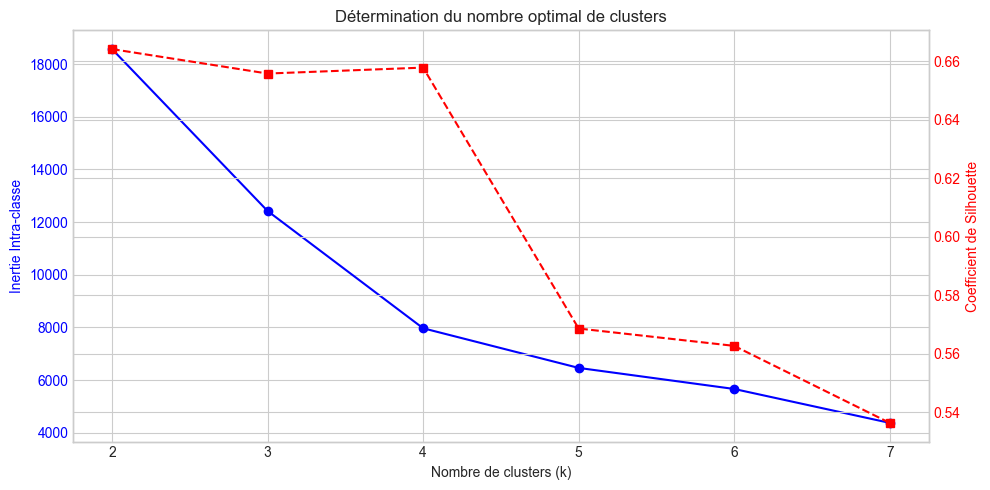

In [40]:
from sklearn.metrics import silhouette_score
# ==============================================================================
# 3. RECHERCHE DU K OPTIMAL (ELBOW & SILHOUETTE)
# ==============================================================================
print("3. Recherche du K optimal (sur échantillon 10k)...")

# Échantillon pour accélérer le calcul
sample_indices = np.random.choice(len(X_scaled), size=min(10000, len(X_scaled)), replace=False)
X_sample = X_scaled[sample_indices]

inertias = []
silhouettes = []
K_range = range(2, 8)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_sample)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sample, km.labels_))

# --- GRAPHIQUE 1 : Méthode du Coude et Silhouette ---
fig, ax1 = plt.subplots(figsize=(10, 5))

# Courbe Inertie (Coude)
ax1.plot(K_range, inertias, 'bo-', label='Inertie (Coude)')
ax1.set_xlabel('Nombre de clusters (k)')
ax1.set_ylabel('Inertie Intra-classe', color='b')
ax1.tick_params(axis='y', labelcolor='b')

# Courbe Silhouette
ax2 = ax1.twinx()
ax2.plot(K_range, silhouettes, 'rs--', label='Silhouette Score')
ax2.set_ylabel('Coefficient de Silhouette', color='r')
ax2.tick_params(axis='y', labelcolor='r')

plt.title('Détermination du nombre optimal de clusters')
fig.tight_layout()
plt.show()

4. Application du modèle final (K=4)...


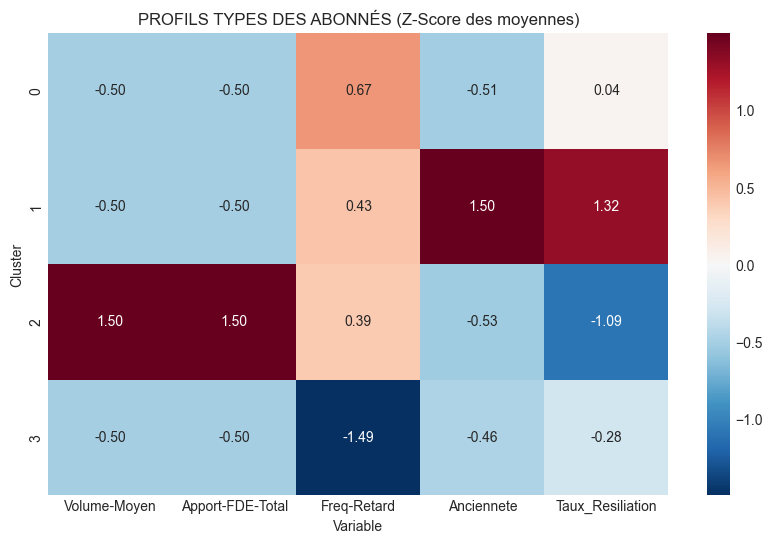


--- MOYENNES RÉELLES PAR CLUSTER ---
   Volume-Moyen  Apport-FDE-Total  Freq-Retard  Anciennete  Taux_Resiliation
0         33.95         54,062.78         0.92        0.03              0.50
1         50.23         77,881.57         0.87        3.46              1.00
2     15,460.38    211,774,393.39         0.86        0.00              0.06
3         29.37         99,812.65         0.44        0.13              0.37


In [41]:
# ==============================================================================
# 4. CLUSTERING FINAL ET ANALYSE DES CENTRES DE GRAVITÉ
# ==============================================================================
print("4. Application du modèle final (K=4)...")
kmeans_final = KMeans(n_clusters=4, random_state=42, n_init=10)
df_client['CLUSTER'] = kmeans_final.fit_predict(X_scaled)

# Calcul des centres de gravité (moyennes normalisées) pour l'interprétation
cluster_centers = pd.DataFrame(
    scaler.inverse_transform(kmeans_final.cluster_centers_), 
    columns=features
)
# On ajoute la moyenne de 'Est_Resilie' (qui n'était pas dans le clustering mais aide à l'interprétation)
cluster_centers['Taux_Resiliation'] = df_client.groupby('CLUSTER')['Est_Resilie'].mean()

# Normalisation Z-Score juste pour la Heatmap (pour bien voir les écarts)
centers_scaled = (cluster_centers - cluster_centers.mean()) / cluster_centers.std()

# --- GRAPHIQUE 2 : Heatmap des Profils ---
plt.figure(figsize=(10, 6))
sns.heatmap(centers_scaled, annot=True, cmap='RdBu_r', center=0, fmt='.2f')
plt.title('PROFILS TYPES DES ABONNÉS (Z-Score des moyennes)')
plt.ylabel('Cluster')
plt.xlabel('Variable')
plt.show()

# Affichage des vraies valeurs moyennes
print("\n--- MOYENNES RÉELLES PAR CLUSTER ---")
print(cluster_centers.round(2))

                                           CLUSTER